# Statistics for Michel electron candidates

# All current available DATA; BKG Study

### Created by Shu, 202603---

### Based on new20251205; the main difference is #opWVF>=3 instead of 4

### Beam events removed

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import os


# ------------------------------------------------------------
# 1️⃣ Define input files
# ------------------------------------------------------------
input_files = []
coinNum = []     # waveform coincidence numbers


# --- Files in current ./statResult_pds
base_dir = "./statResult_pdsBKG"
run_numbers = [
    "28891BKG"
]

for r in run_numbers:
    input_files.append(os.path.join(base_dir, f"print_count_{r}.txt"))


# ------------------------------------------------------------
# 2️⃣ Read waveform coincidence counts
# ------------------------------------------------------------
for fname in input_files:
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            parts = line.split(":")
            if len(parts) >= 2:
                try:
                    number = int(parts[1].strip())
                    coinNum.append(number)
                except ValueError:
                    print(f"[WARN] Could not convert '{parts[1].strip()}' in {fname} to an integer.")


# ------------------------------------------------------------
# ✅ Summary
# ------------------------------------------------------------
print("Track candidates (TPC cut)  : xxx")
print("Track candidates with NO wvf: xxx")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * 5000)

# optional: convert to numpy array
coinNum = np.array(coinNum, dtype=int)

# optional: save it
#np.save("coinNum.npy", coinNum)
#np.savetxt("coinNum.txt", coinNum, fmt="%d")

Track candidates (TPC cut)  : xxx
Track candidates with NO wvf: xxx
Number of track candidates  : 123508



Candidates with #opWvf>=3:  101864 / 123508 (82.48%)


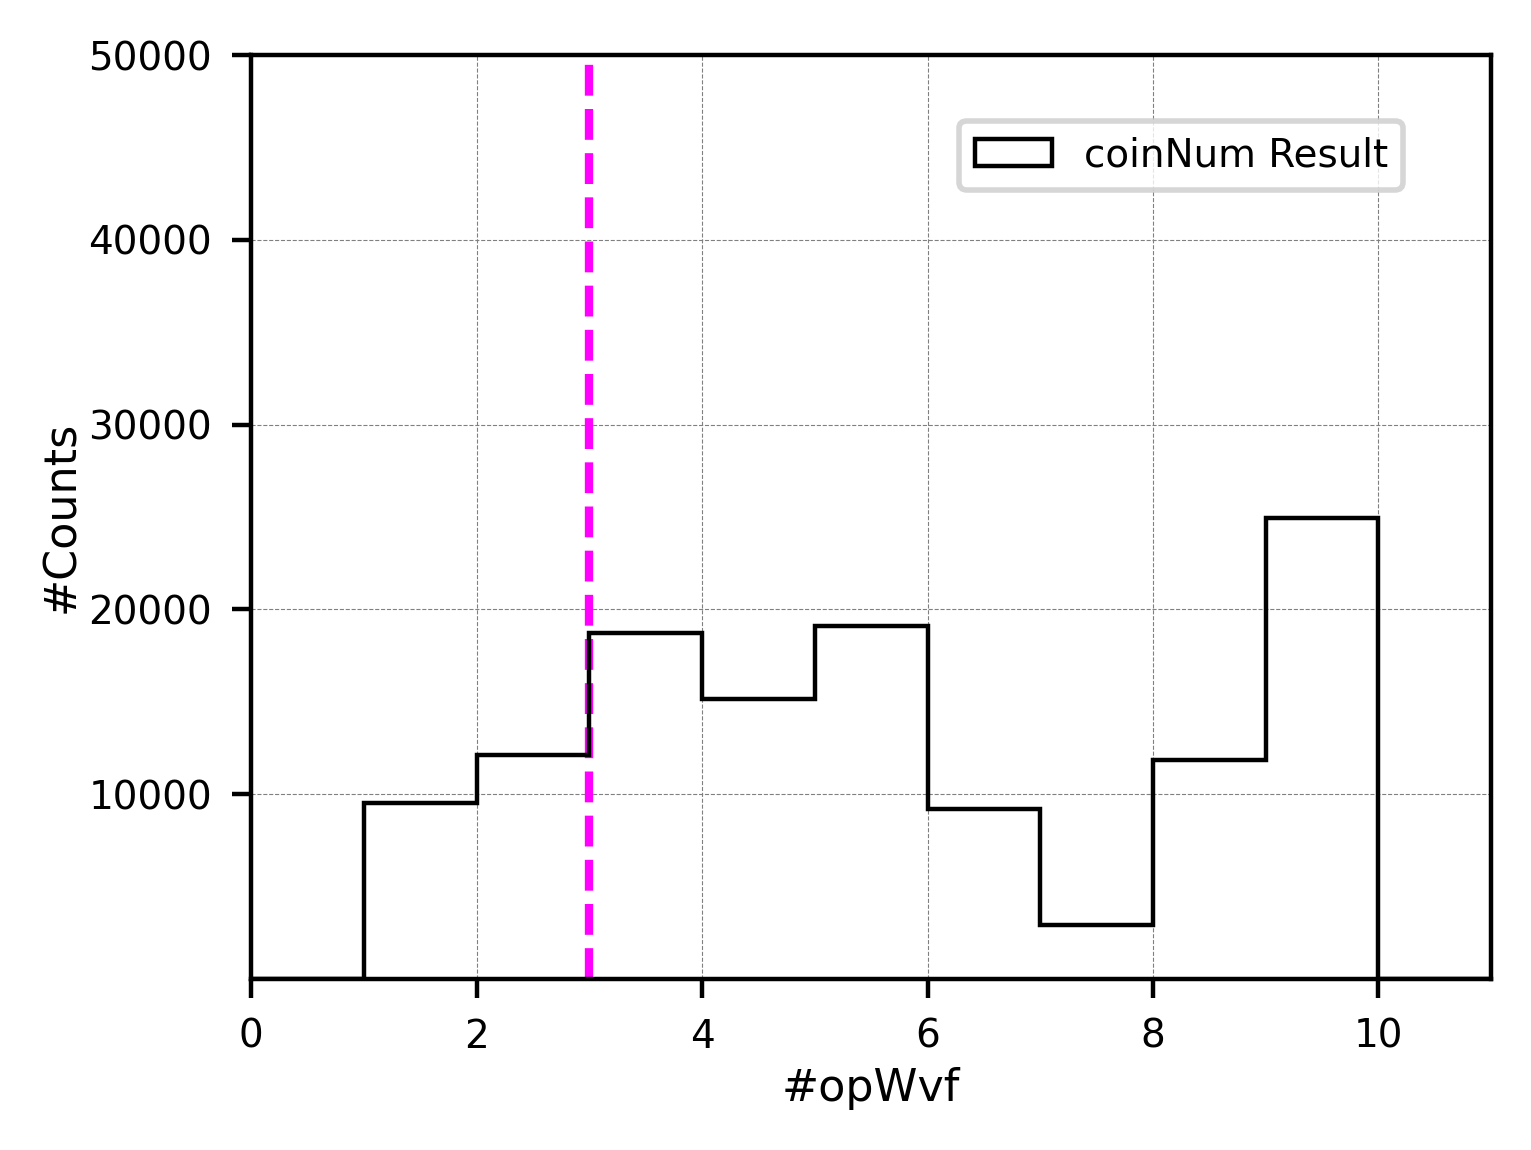

In [6]:
#Apply preliminary cut #opWvf >=3:=====================
coinNum_cut4 = []
coinNum_trueE_cut4 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]

    if coin >=3:
        coinNum_cut4.append(coin)

print("\nCandidates with #opWvf>=3: ", len(coinNum_cut4), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut4)/len(coinNum)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 50000], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 50000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 3) (This can be taken as "PDS Cut 1")

In [7]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    third_time: Optional[int] = None             # NEW
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None      # NEW
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[str] = None
    # muon
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    # michel
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None
    # third peak
    th_leftTurn: Optional[int] = None            # NEW
    th_rightTurn: Optional[int] = None           # NEW
    th_leftHeight: Optional[float] = None        # NEW
    th_rightHeight: Optional[float] = None       # NEW
    # Michel-level attributes
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None            # ✅ NEW



# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None



def read_total_files(files, dates, kind="muon"):
    """
    Read *_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    evID, trID = parse_event_track(path_part)
                    rec = {"eventID": evID, "trackID": trID, "date": date}

                    if kind == "muon":
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    elif kind == "michel":
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })
                    elif kind == "third":
                        rec.update({
                            "third_time": time_val,
                            "third_intensity": inten_val,
                            "th_leftTurn": left_turn,
                            "th_leftHeight": left_h,
                            "th_rightTurn": right_turn,
                            "th_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records




def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



# ------------------- Load data -------------------------
# dates here are in fact run number
dates = ["28891BKG"] 

muon_files   = [f"./statResult_pdsBKG/muon_total_{d}.txt" for d in dates]
michel_files = [f"./statResult_pdsBKG/michel_total_{d}.txt" for d in dates]
third_files  = [f"./statResult_pdsBKG/third_total_{d}.txt" for d in dates]

muon_records   = read_total_files(muon_files, dates, kind="muon")
michel_records = read_total_files(michel_files, dates, kind="michel")
third_records  = read_total_files(third_files, dates, kind="third")

# --- plain text attributes ---
posX     = read_plain_files([f"./statResult_pdsBKG/posX_extract_{d}.txt" for d in dates])
posY     = read_plain_files([f"./statResult_pdsBKG/posY_extract_{d}.txt" for d in dates])
posZ     = read_plain_files([f"./statResult_pdsBKG/posZ_extract_{d}.txt" for d in dates])
miScore  = read_plain_files([f"./statResult_pdsBKG/michelScore_extract_{d}.txt" for d in dates])
miHits   = read_plain_files([f"./statResult_pdsBKG/michelHits_extract_{d}.txt" for d in dates], cast_type=int)









# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(
    len(muon_records), len(michel_records), len(third_records),
    len(posX), len(posY), len(posZ),
    len(miScore), len(miHits)
)

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]
    rec_th = third_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID", rec_th.get("eventID"))),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID", rec_th.get("trackID"))),
        date=rec_mu.get("date", rec_mi.get("date", rec_th.get("date"))),

        # muon
        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        # michel
        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),
        michel_score=miScore[i],
        michel_hits=miHits[i],

        # third
        third_time=rec_th.get("third_time"),
        third_intensity=rec_th.get("third_intensity"),
        th_leftTurn=rec_th.get("th_leftTurn"),
        th_leftHeight=rec_th.get("th_leftHeight"),
        th_rightTurn=rec_th.get("th_rightTurn"),
        th_rightHeight=rec_th.get("th_rightHeight"),

        # physical properties
        posX=posX[i], posY=posY[i], posZ=posZ[i]
    )
    events_veryInitial.append(ev)

print("Very initial dataset:", len(events_veryInitial))

example = events_veryInitial[0]
print("\nExample Event (index 0):")
for field, value in vars(example).items():
    print(f"  {field:20s}: {value}")









#Apply cuts on peak intensities-----------------------------
events_reco_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity

    ms = ev.michel_score
    mh = ev.michel_hits

    if muIntensity > 0.3  and miIntensity > -0.1  and ms >= 0.0 and mh < 3:#mu & mi are cuts in following block already!
        events_reco_initial.append(ev)


print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))






Very initial dataset: 29808

Example Event (index 0):
  muon_time           : 61
  michel_time         : 141
  third_time          : 115
  muon_intensity      : 54.6987
  michel_intensity    : 1.15436
  third_intensity     : 1.01224
  posX                : -345.876
  posY                : 132.598
  posZ                : 426.785
  eventID             : 100011
  trackID             : 0
  date                : 28891BKG
  mu_leftTurn         : 37
  mu_rightTurn        : 107
  mu_leftHeight       : 61.5859
  mu_rightHeight      : 54.6987
  mi_leftTurn         : 130
  mi_rightTurn        : 185
  mi_leftHeight       : 1.15436
  mi_rightHeight      : 4.3476
  th_leftTurn         : 107
  th_rightTurn        : 130
  th_leftHeight       : 1.01224
  th_rightHeight      : 3.08895
  michel_score        : 0.00611781
  michel_hits         : 1

Dataset after initial intensity-cut----------------------
Michel initial dataset   :  29804


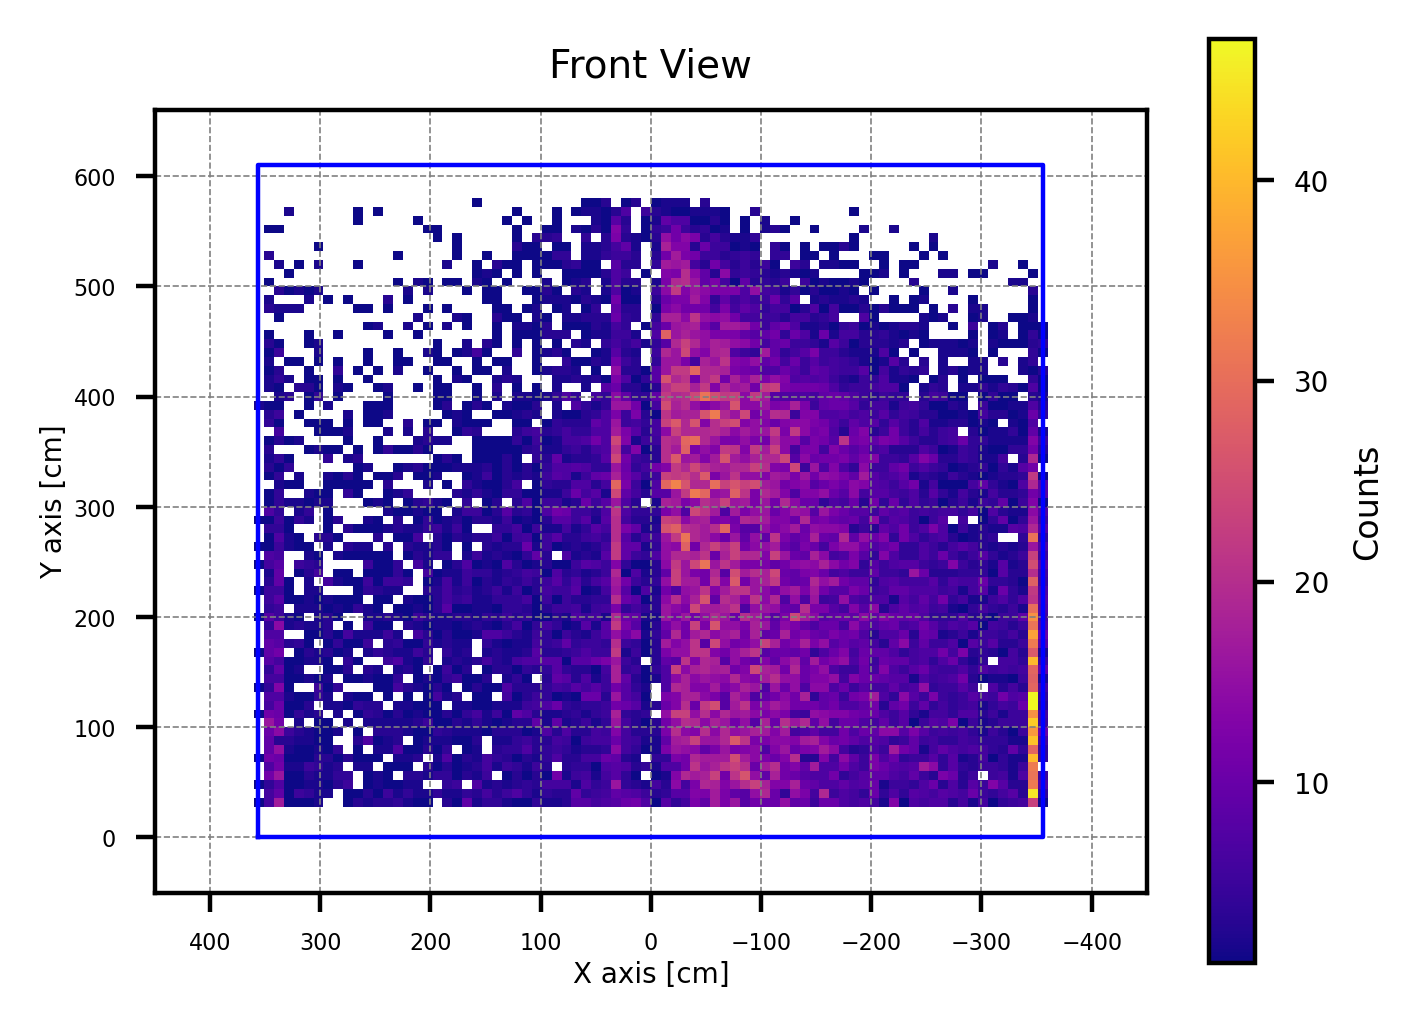

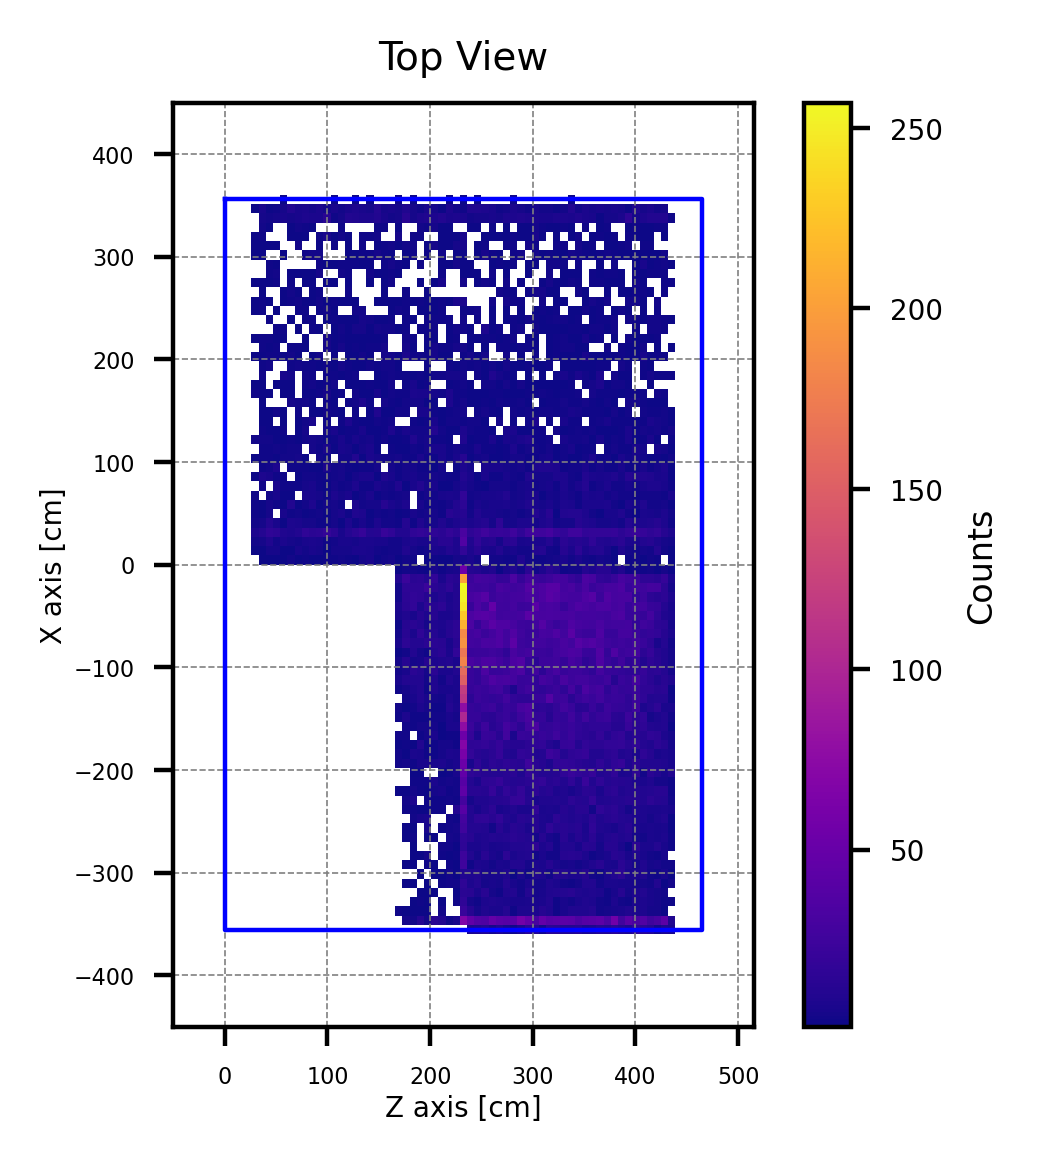


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  23010 (77.20%)
# of X >= 0:  6794 (22.80%)


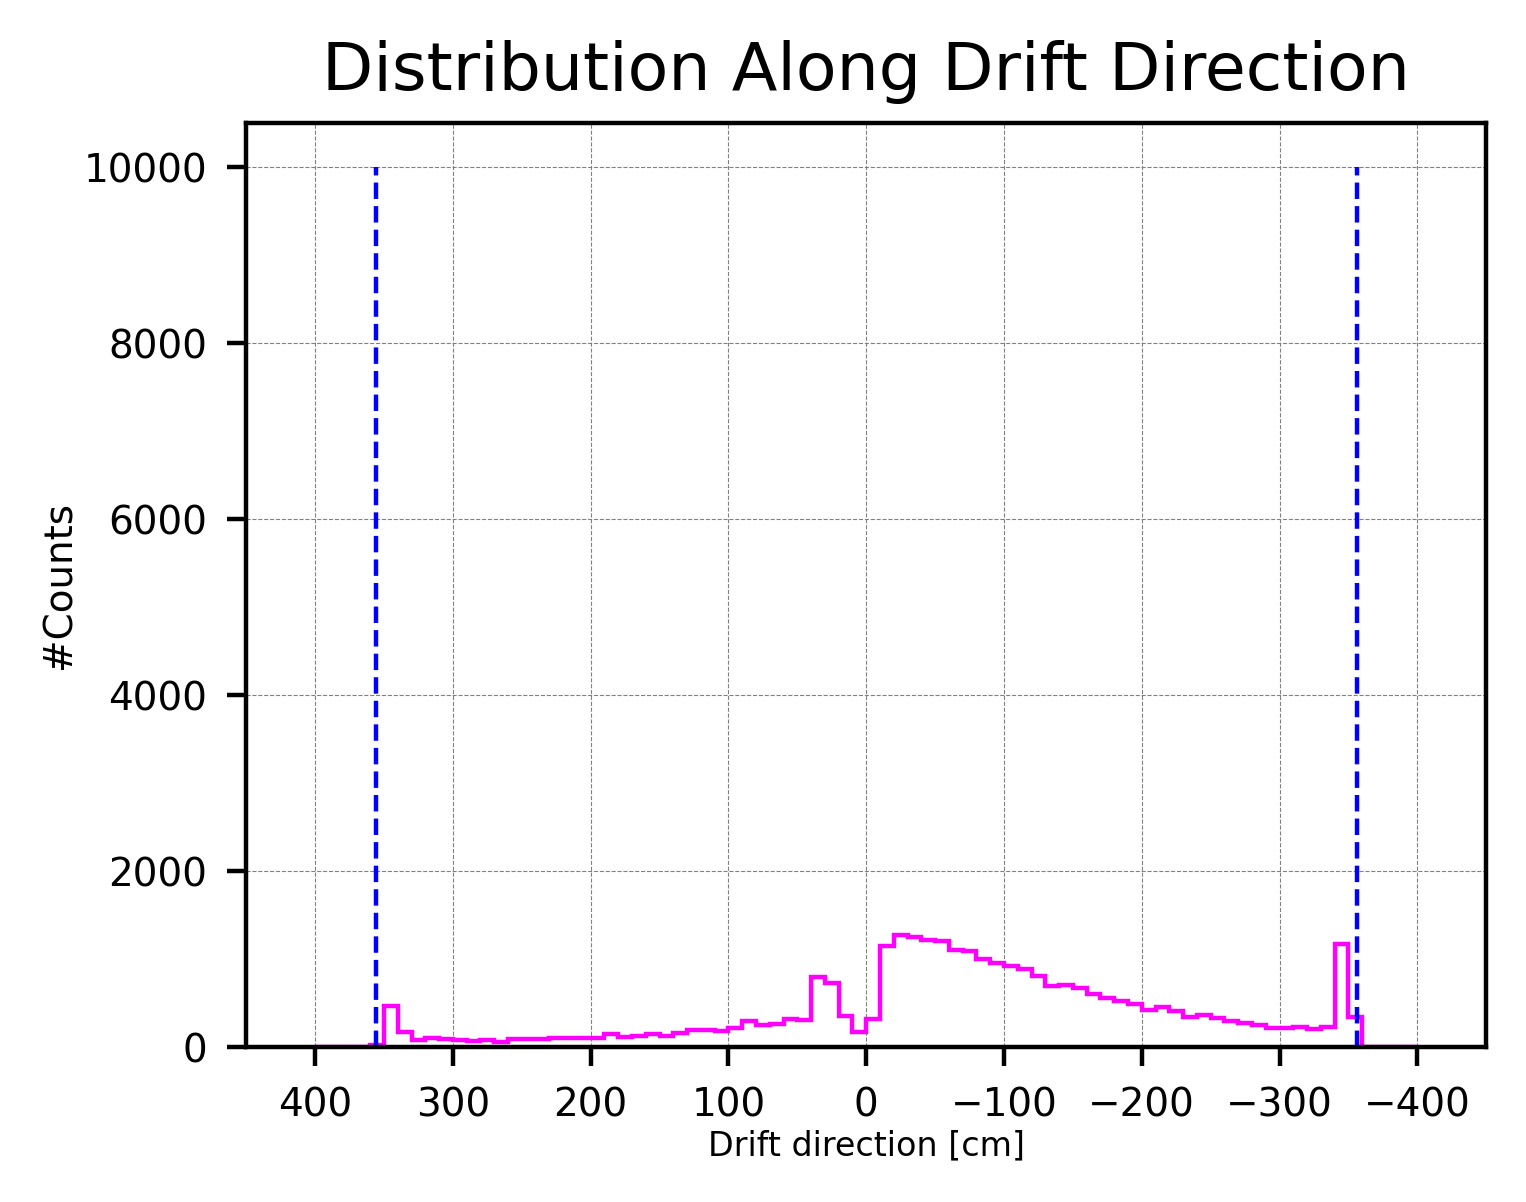

In [8]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))      




#============================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(posX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


plt.xlim(-450, 450)
plt.xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylabel('#Counts', labelpad=1, fontsize=7)
#plt.ylim(0.1, 5000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution Along Drift Direction', fontsize=12)
plt.show()  






#### Quick distance test ---

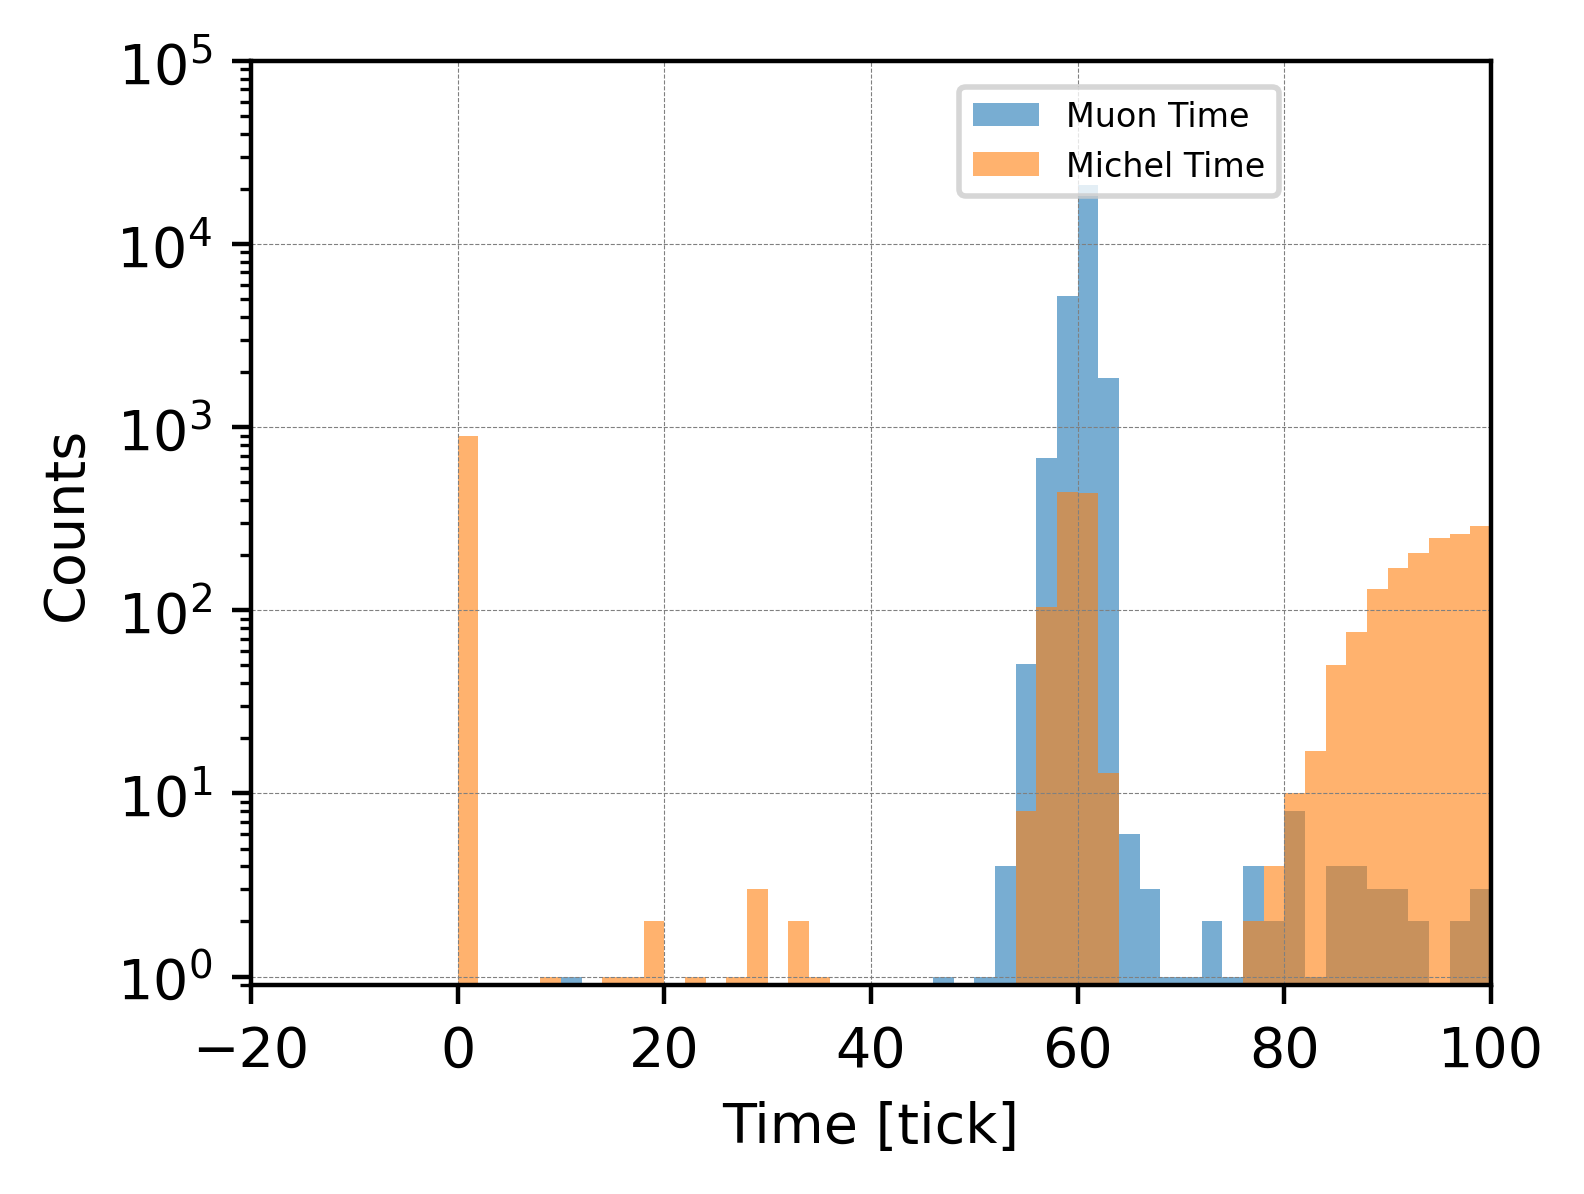

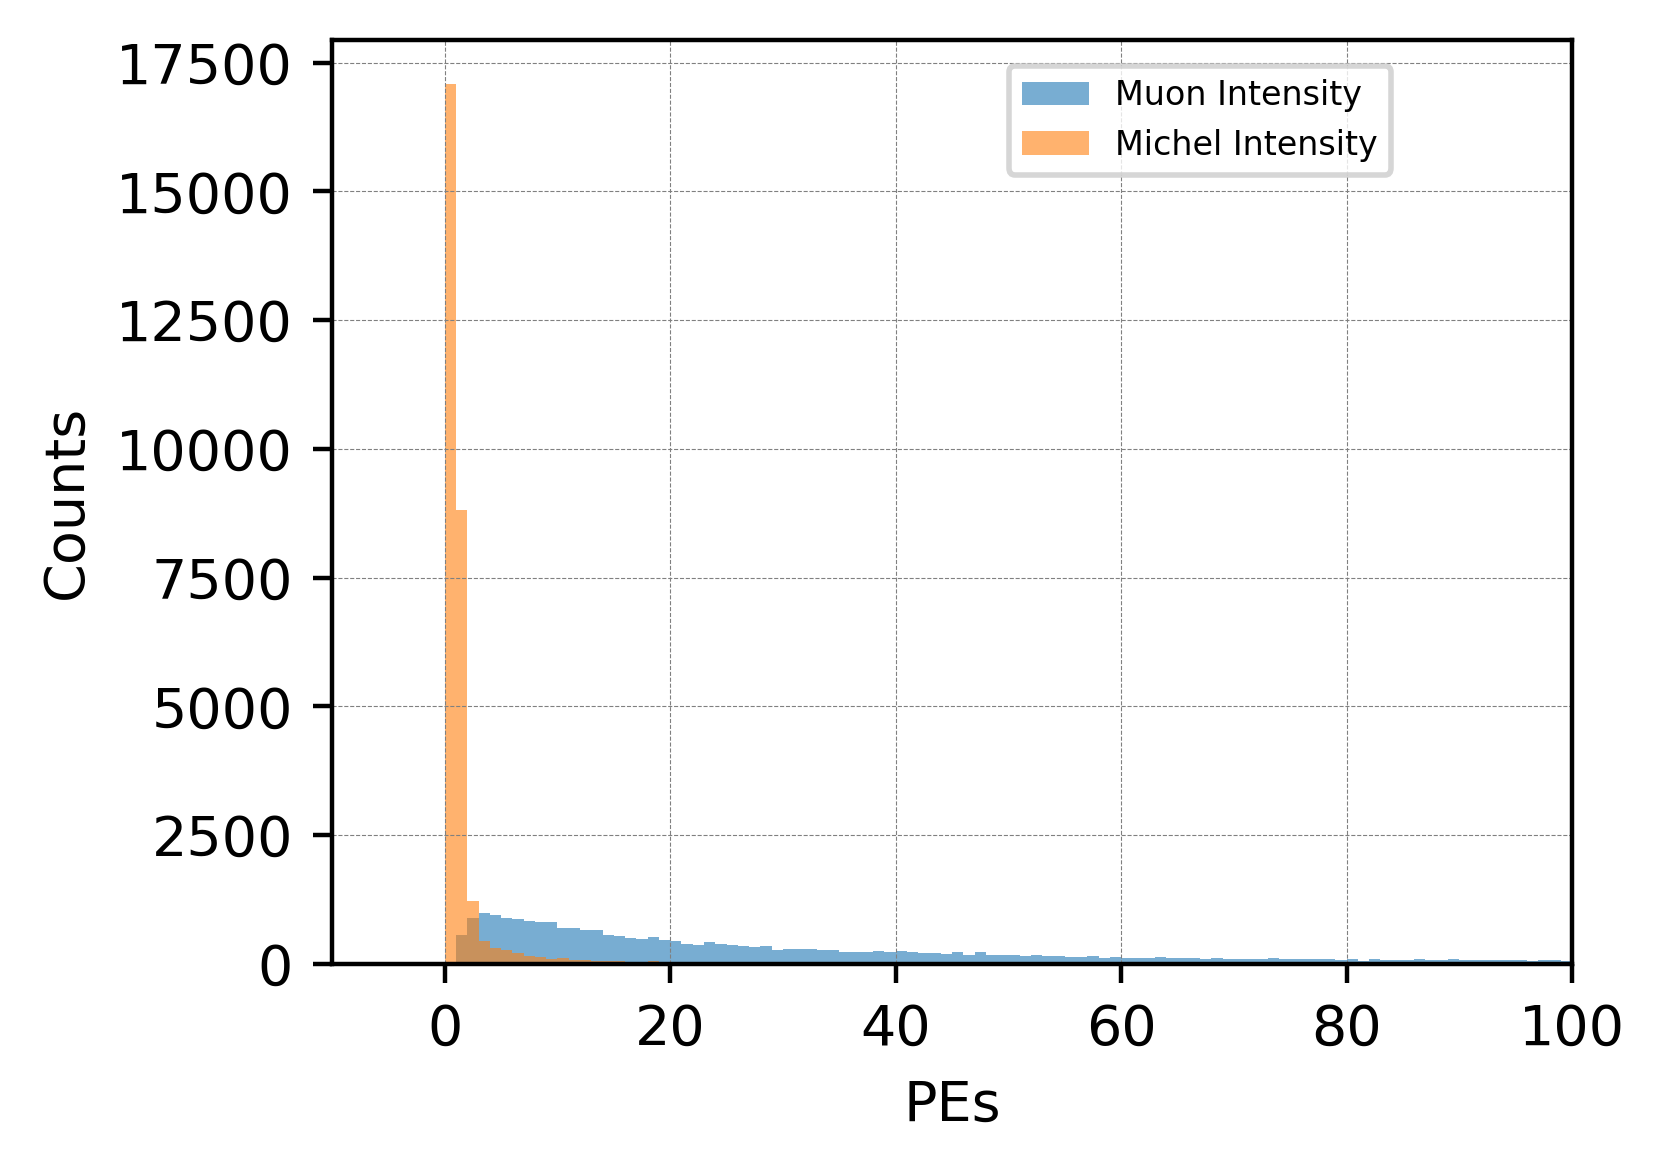

In [9]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]



#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 2  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Time [tick]')
plt.ylabel('Counts')
plt.yscale('log')
#plt.xlim(-20, 1024)
plt.xlim(-20, 100)
plt.ylim(0.9, 100000)
#plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
#plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









 





<br />
<br />
<br />
<br />


### Purification / cut 2: remove abnormal muon signals (constrain muTime to [50, 70])

Muon events selection (mu peak constrained to [50, 65]):
Updated Muon events:  28733 / 29804 (96.41%)
Length of time_difference (Updated):  28733
Adding muTIme < miTime:
Updated Muon events:  27833 / 29804 (93.39%)


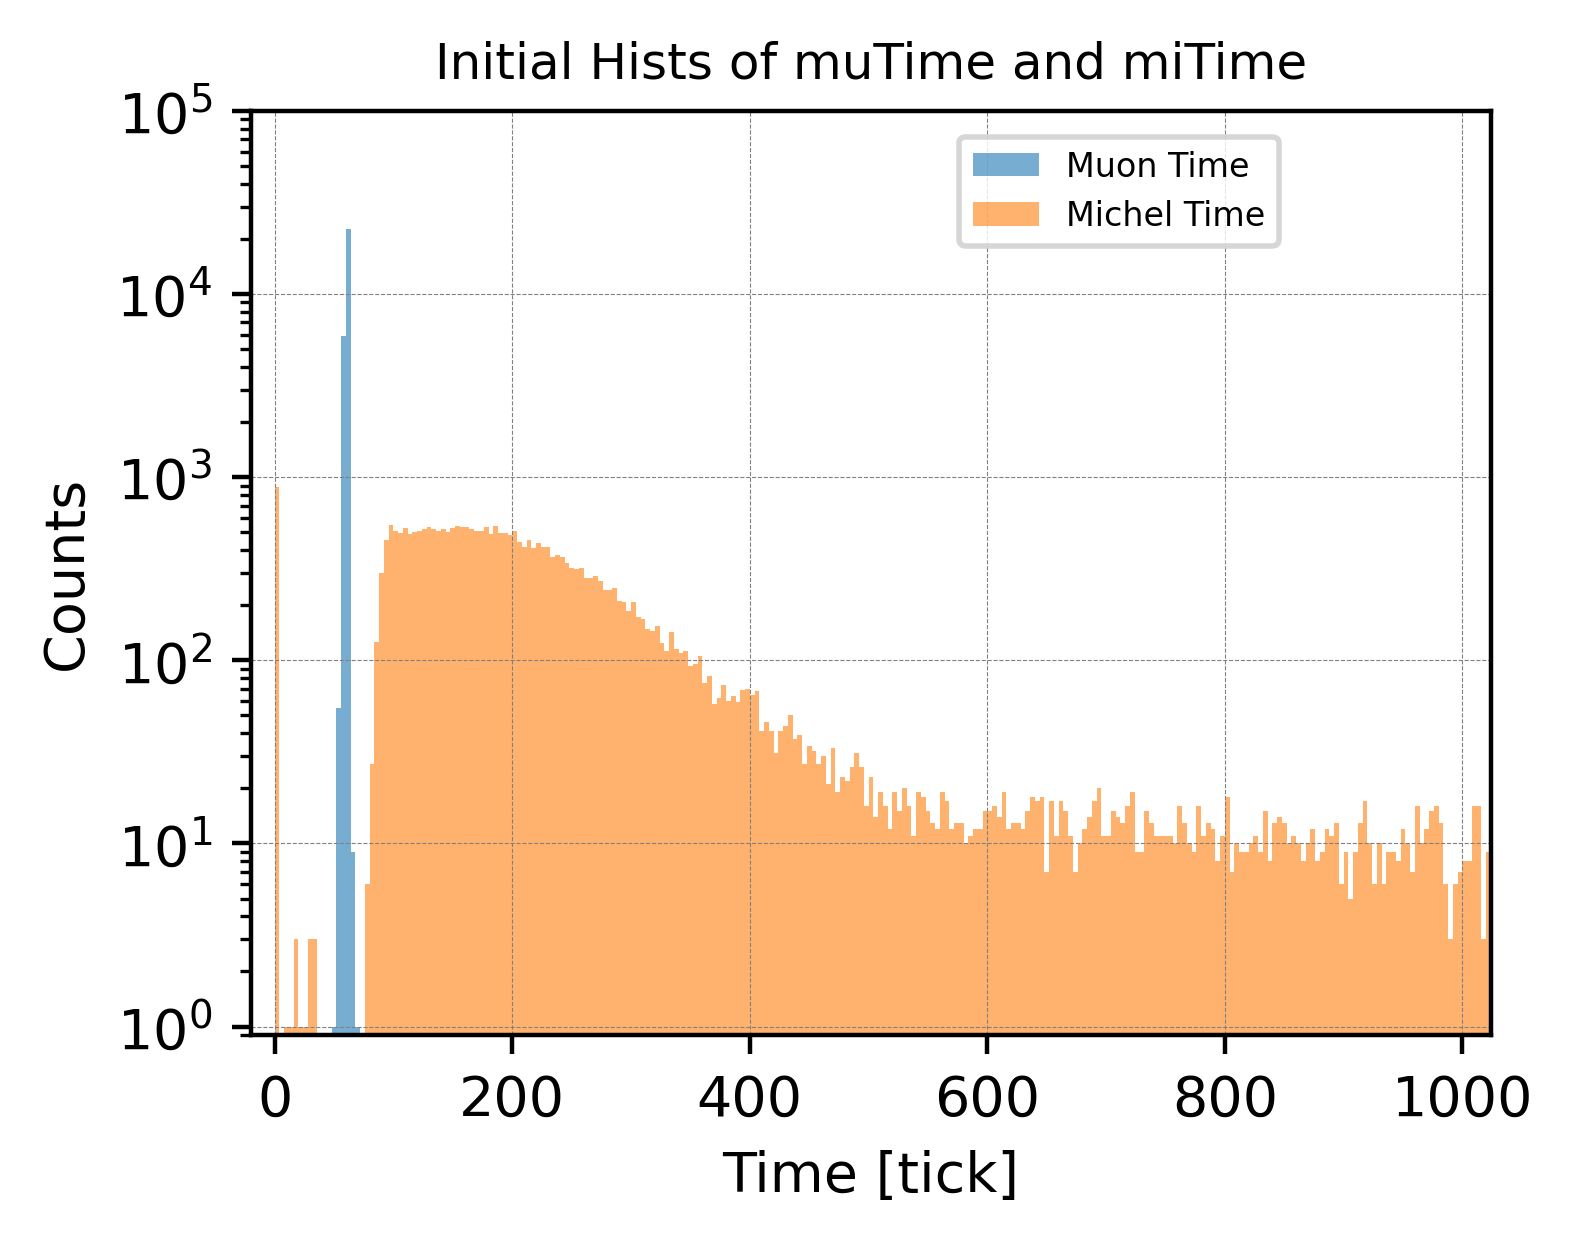




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  28733


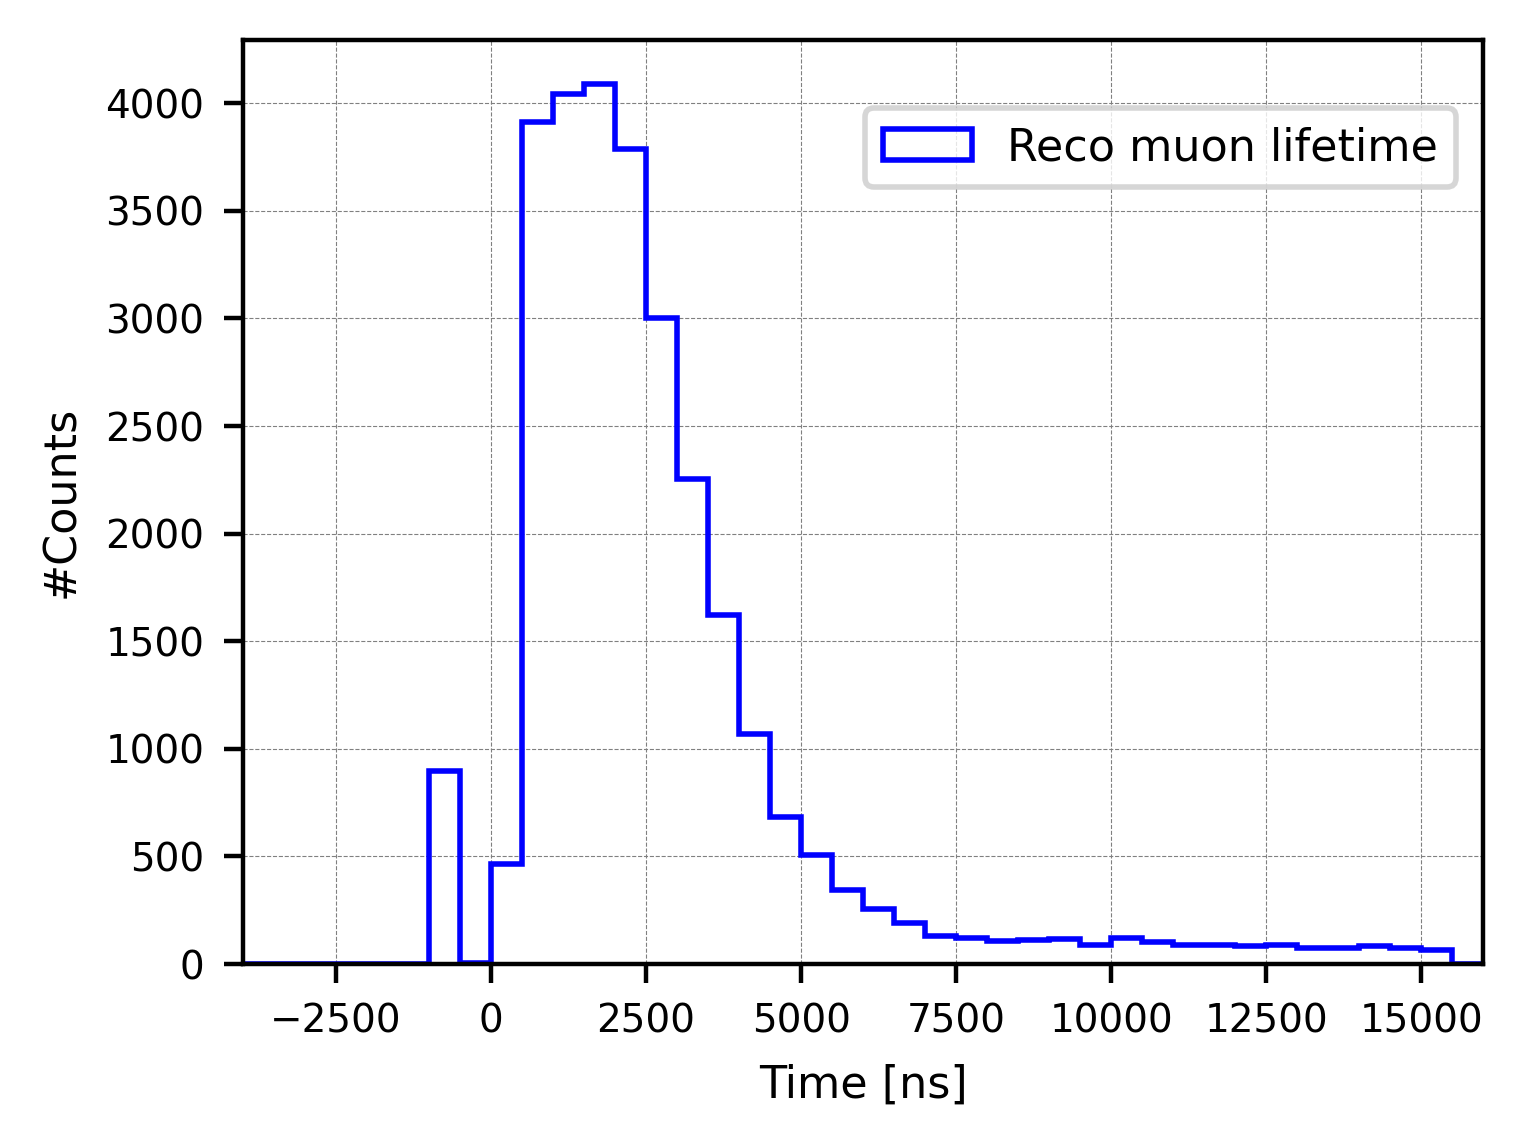

In [10]:
events_reco_update1 = []

lifetime_reco_update1 = []

events_reco_update1X = []


for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time

    #if 50 <= muTime <= 65:
    if 50 <= muTime <= 70:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if muTime < miTime:
            events_reco_update1X.append(ev)


print("Muon events selection (mu peak constrained to [50, 65]):")
print("Updated Muon events: ", len(events_reco_update1), "/", len(events_reco_initial),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))


print("Adding muTIme < miTime:")
print("Updated Muon events: ", len(events_reco_update1X), "/", len(events_reco_initial),
       "({:.2f}%)".format(len(events_reco_update1X)/len(events_reco_initial)*100))








#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Time [tick]')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.ylim(0.9, 100000)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()








# #Initial_X Mu and Michel time distributions=================================================
# plt.figure(figsize=(4,3),dpi=400)

# muTime_update = [ev.muon_time for ev in events_reco_update1X]
# miTime_update = [ev.michel_time for ev in events_reco_update1X]


# # Example: set your bin parameters
# range_min_initial = 0
# range_max_initial = 1024
# bin_width_initial = 4  # You can change this value; default: 4
# bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# # Plot histograms on the same canvas
# plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
# plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

# plt.xlabel('Time [tick]')
# plt.ylabel('Counts')
# plt.yscale('log')
# plt.xlim(-20, 1024)
# plt.ylim(0.9, 100000)
# #plt.title('Initial Hists of muTime and miTime', fontsize=9)

# plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
# plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

# plt.show()






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---



print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(-4000, 16000)
#plt.ylim(0.9, 5000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification / cut 3: remove events with unphysical lifetime 
#### (20251022): lifetime cut should be >0 here 




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  27833


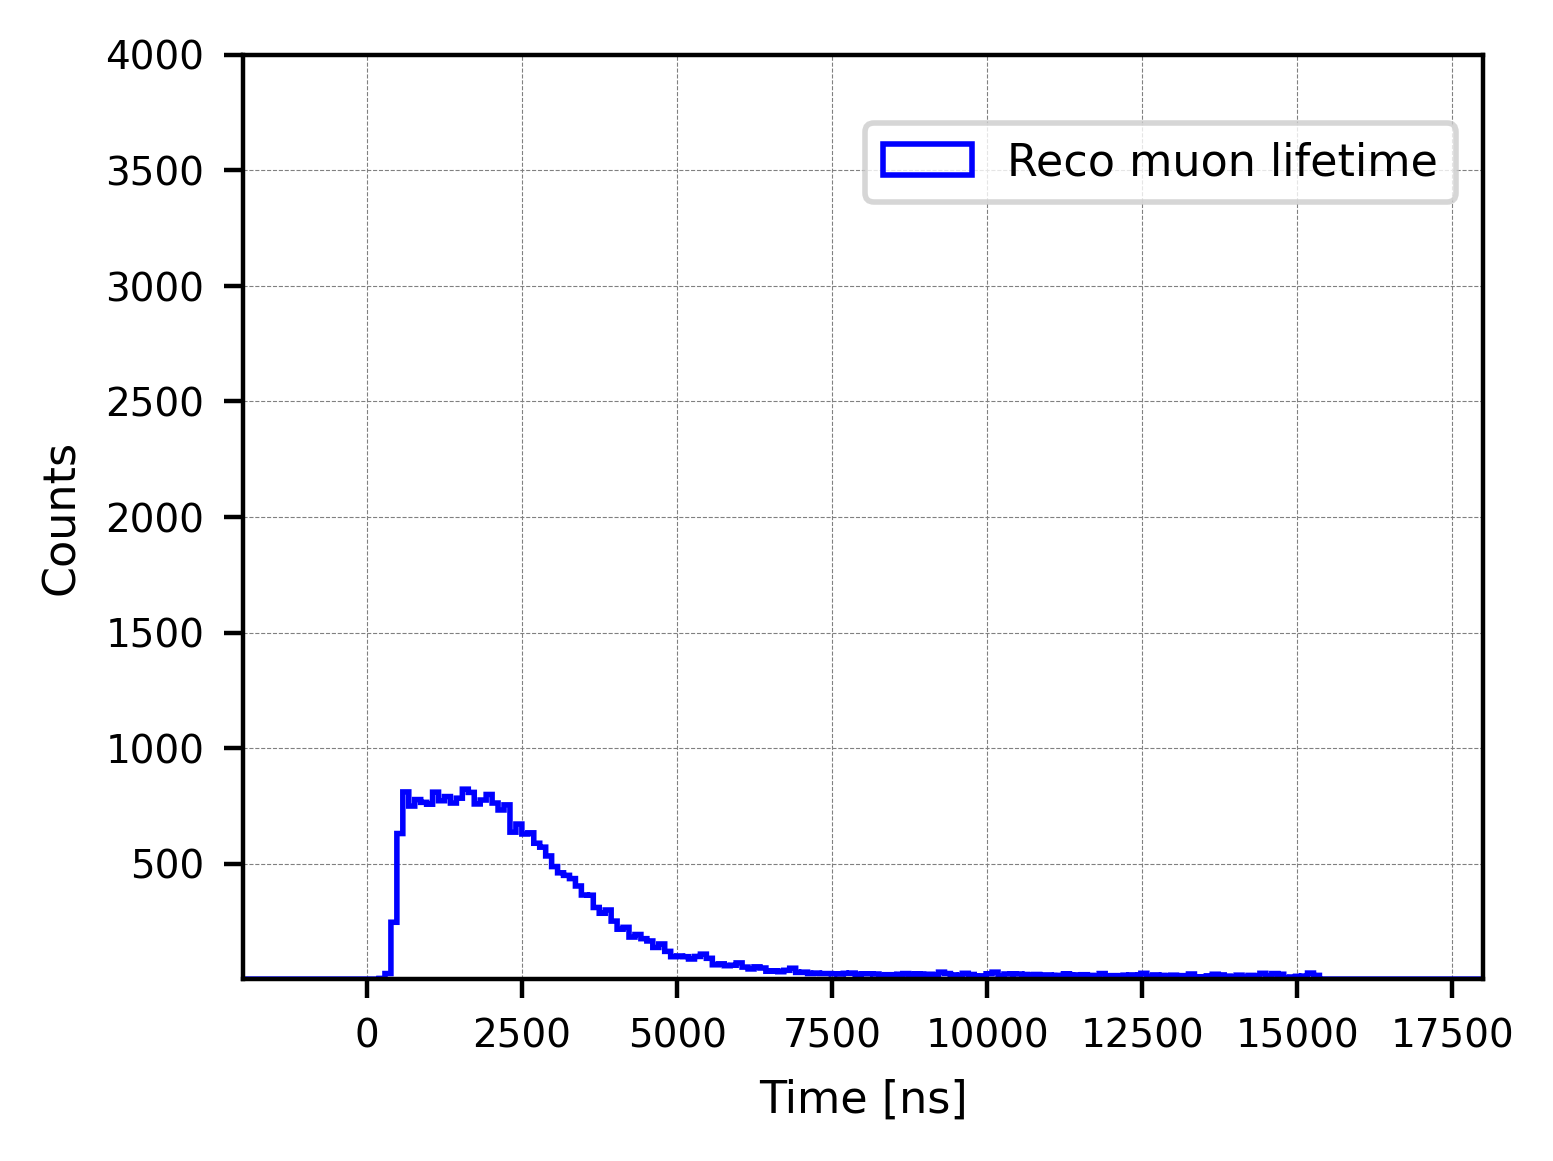

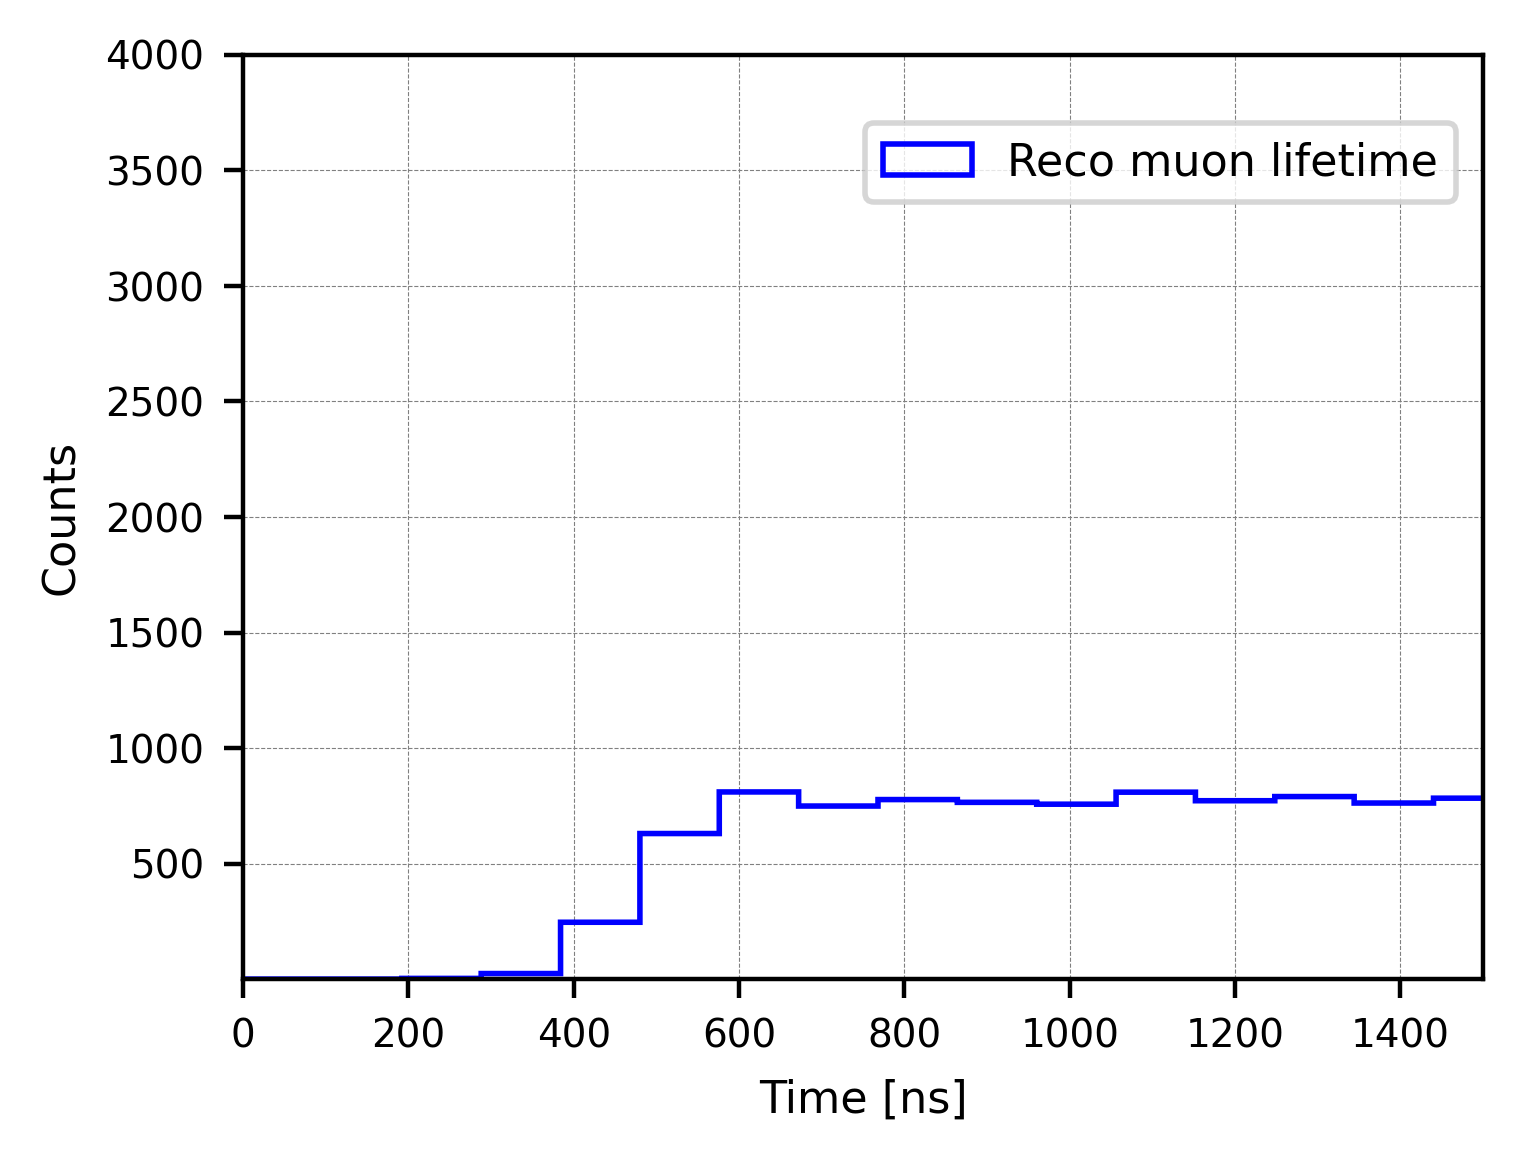

In [11]:
events_reco_update2 = []#Dataset after Purification 2---
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    if 0 <= timeDiff: #keep physical events here---
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(events_reco_update2))






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 96
range_min = -96000
range_max = 96000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

#plt.plot([-2000, 20000], [5, 5], color="green", linewidth=0.8, linestyle='--', label='y = 5')
#plt.plot([-2000, 20000], [10, 10], color="magenta", linewidth=0.8, linestyle='--', label='y = 10')

plt.xlim(-2000, 18000)
plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# zoomed-in plot--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 96
range_min = -96000
range_max = 96000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(0, 1500)
plt.ylim(0.9, 4000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Dataset After purification 3 [RecoT>0]:

In [12]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))



#Rise is intensity related: rise ~ intensity / time; 20251207---
#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45



#New calculated reco & true lifetime lists:
recoLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)

#    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
#    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)
    left_slope = (2.5 * ev.mi_leftHeight - 0.45) / (miTime - ev.mi_leftTurn) #20251207---
    right_slope = (2.5 * ev.mi_rightHeight - 0.45) / (ev.mi_rightTurn - miTime)


#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        third_intensity=ev.third_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        michel_score=ev.michel_score,
        michel_hits=ev.michel_hits, 
        reco_lifetime=reco_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))




Size of events_reco_update2 (previous class):  27833
Size of lifetime_reco_update2               :  27833

Length of final dataset in format of new class:  27833


<br />
<br />
<br />
<br />

### MC DATA Intensity Comparison:

In [13]:
from scipy.stats import gaussian_kde
from matplotlib import colors
import matplotlib.patches as mpatches
from iminuit import Minuit
import numpy as np
import matplotlib.pyplot as plt

#============================================================
# 1. Prepare arrays
# ============================================================
recoLife_diff = [ev.reco_lifetime for ev in events_newClass]
muInt_diff = [ev.muon_intensity for ev in events_newClass]
miInt_diff = [ev.michel_intensity for ev in events_newClass]
thirdInt_diff = [ev.third_intensity for ev in events_newClass]
X_diff = [ev.posX for ev in events_newClass]

muInt_diff = np.array(muInt_diff, dtype=float)
miInt_diff = np.array(miInt_diff, dtype=float)



print("Array sizes:")
print(f"  DATA muon          : {len(muInt_diff)}")
print(f"  DATA Michel        : {len(miInt_diff)}")




Array sizes:
  DATA muon          : 27833
  DATA Michel        : 27833


<br />
<br />
<br />
<br />

### Purification 4:  Michel Intensity / Muon Intensity:

After lifetime cut (cut 3):
# Events:  27833

Total events        = 27833
Mean Michel score   = 0.001
N(score > 0.8)      = 0
Fraction > 0.8      = 0.000

(michel Intensity) / (muon intensity) (Cut 4):----------
Efficiency (cut4 / cut3):  5830 / 27833 (20.95%)

Total events        = 5830
Mean Michel score   = 0.001
N(score > 0.8)      = 0
Fraction > 0.8      = 0.000


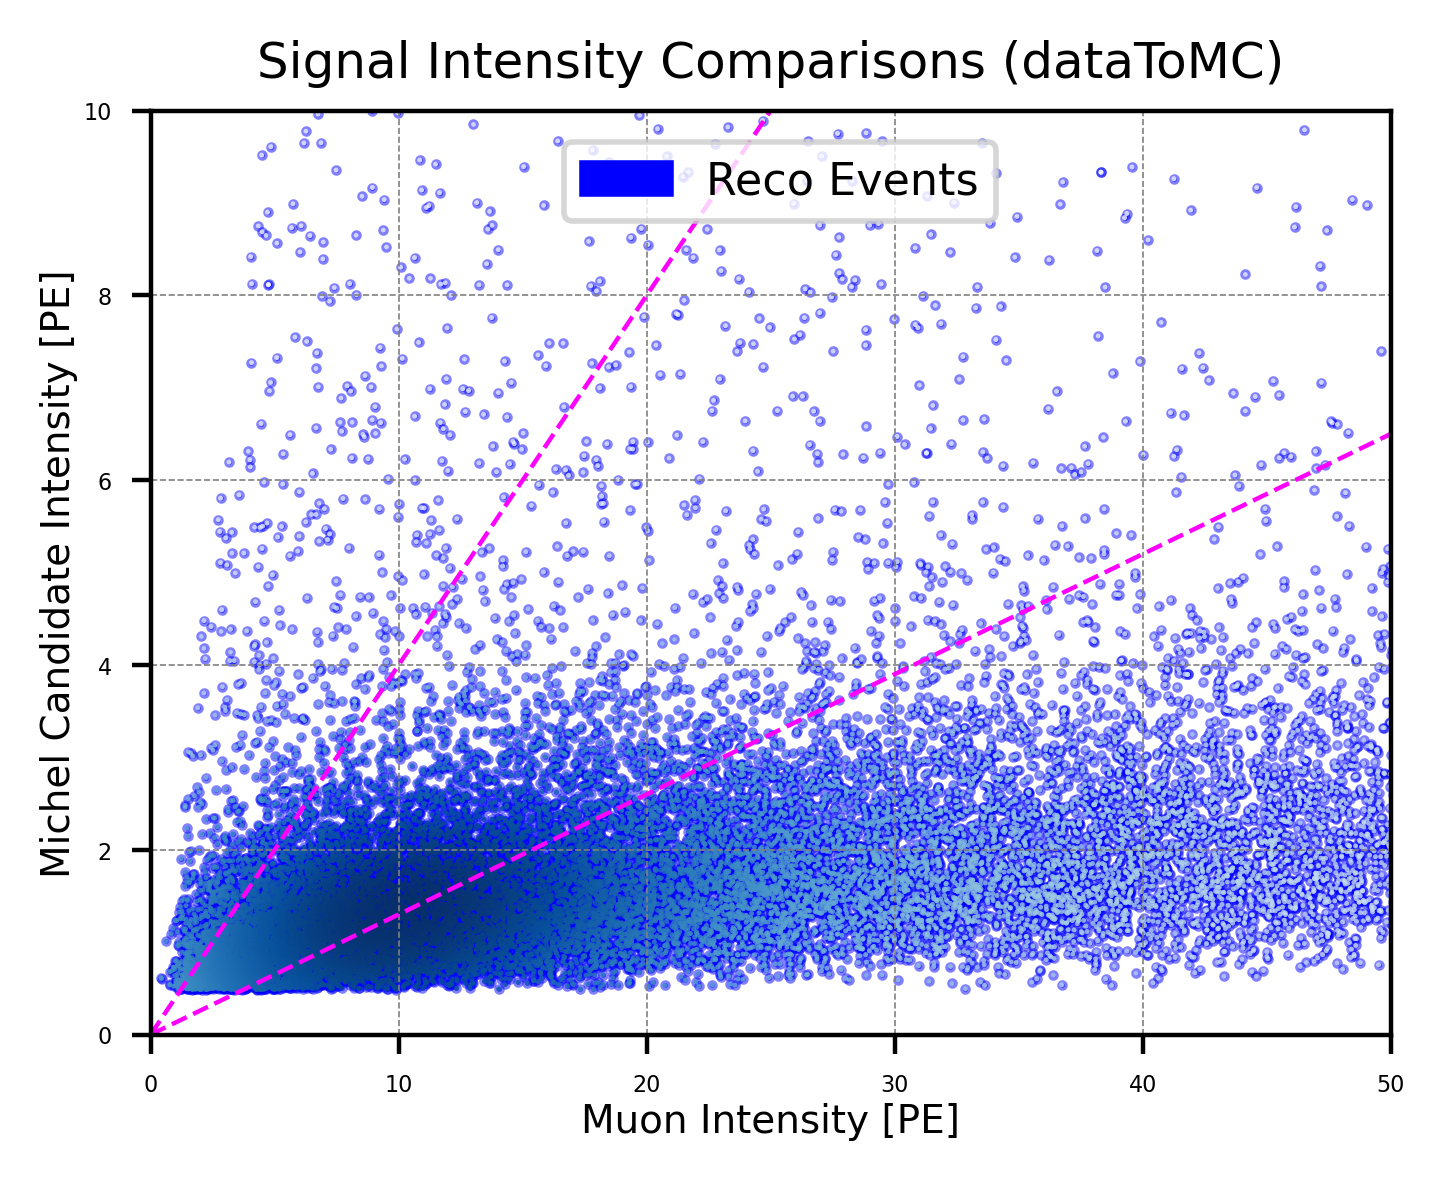


For Purify 4----------------------
ChatGPT (20260311): The 1D Michel scaling is a useful first-order correction, 
but the ratio variable carries additional information that is not captured by that 1D correction.


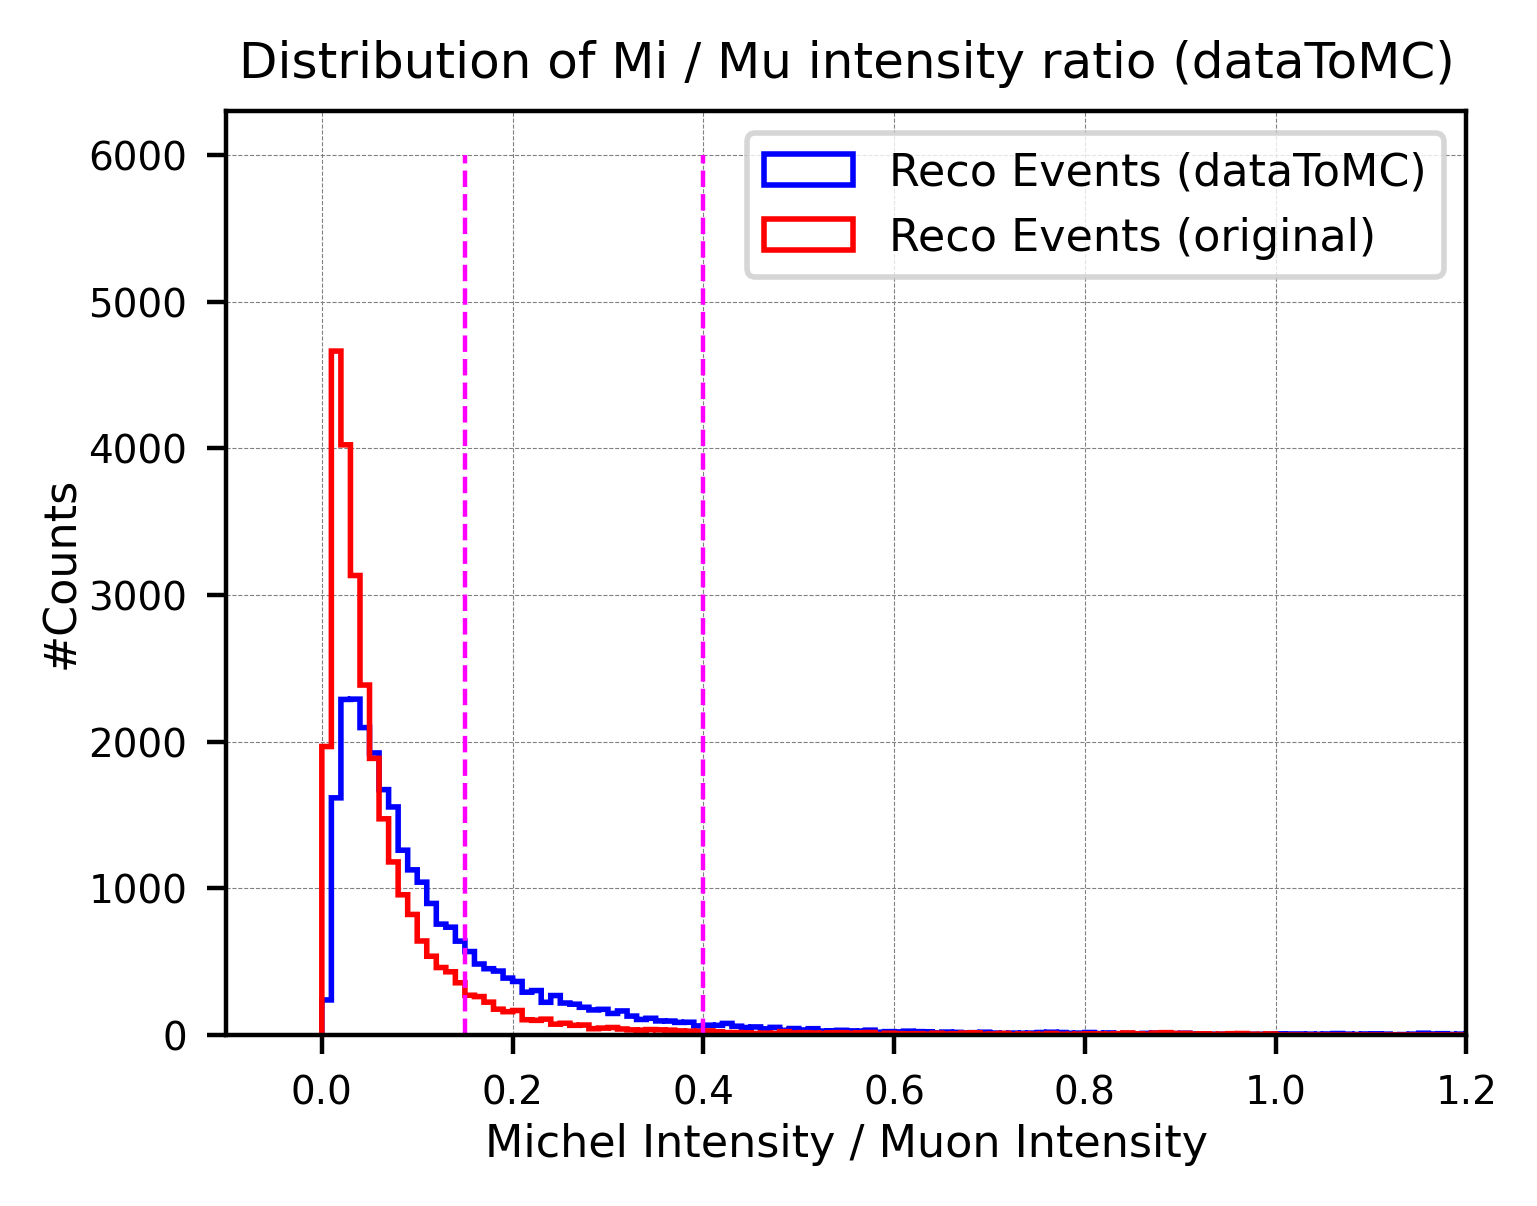

In [14]:
#Adjust and apply scaling===========================================
x_scale_muMC = 1.047 #Best value: 1.047
x_shift_muMC = -0.007 #Best value: -0.007

x_scale_miMC = 0.469 #0.469
x_shift_miMC = 0.072 #0.072

x_scale_thirdMC = 0.522 #0.522
x_shift_thirdMC = 0.136 #0.136


# Convert DATA intensity back to MC-equivalent intensity
def mu_dataToMC(value_data):

    return (value_data - x_shift_muMC) / x_scale_muMC

def michel_dataToMC(value_data):

    return (value_data - x_shift_miMC) / x_scale_miMC

def third_dataToMC(value_data):

    return (value_data - x_shift_thirdMC) / x_scale_thirdMC




#Michel Intensity Cut (Cut 4)================================================
print("After lifetime cut (cut 3):")

print("# Events: ", len(events_newClass))

mScore_total = [ev.michel_score for ev in events_newClass]
#Michel score:
mean_score = sum(mScore_total) / len(mScore_total)
n_high = sum(1 for s in mScore_total if s > 0.8)
frac_high = n_high / len(mScore_total)
print(f"\nTotal events        = {len(mScore_total)}")
print(f"Mean Michel score   = {mean_score:.3f}")
print(f"N(score > 0.8)      = {n_high}")
print(f"Fraction > 0.8      = {frac_high:.3f}")



thre1 = 7.5 / 50
thre2 = 40 / 100

# filter the actual events
events_total_purify4 = [
    ev for ev in events_newClass

#    if ev.muon_intensity != 0 and thre1 <  ev.michel_intensity / ev.muon_intensity < thre2

    #Shifted and scaled data---
    if ev.muon_intensity != 0 and thre1 < michel_dataToMC(ev.michel_intensity) / mu_dataToMC(ev.muon_intensity) < thre2

]
#-------------------------------

print("\n(michel Intensity) / (muon intensity) (Cut 4):----------")

print("Efficiency (cut4 / cut3): ", len(events_total_purify4), "/", len(events_newClass),
      "({:.2f}%)".format(len(events_total_purify4)/len(events_newClass)*100))


mScore_purify4 = [ev.michel_score for ev in events_total_purify4]
#Michel score:
mean_score_purify4 = sum(mScore_purify4) / len(mScore_purify4)
n_high_purify4 = sum(1 for s in mScore_purify4 if s > 0.8)
frac_high_purify4 = n_high_purify4 / len(mScore_purify4)
print(f"\nTotal events        = {len(mScore_purify4)}")
print(f"Mean Michel score   = {mean_score_purify4:.3f}")
print(f"N(score > 0.8)      = {n_high_purify4}")
print(f"Fraction > 0.8      = {frac_high_purify4:.3f}")




# For drawing and comparison------------------------------
muInt_dataToMC = mu_dataToMC(muInt_diff)
miInt_dataToMC = michel_dataToMC(miInt_diff)



# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_dataToMC), np.array(miInt_dataToMC)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 500], [0, 65], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 1000], [0, 400], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 50) #(-5, 400)
plt.ylim(0, 10) #(-5, 60)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons (dataToMC)', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()






#Ratio distribution===================================
print("\nFor Purify 4----------------------")
print("ChatGPT (20260311): The 1D Michel scaling is a useful first-order correction, " \
"\nbut the ratio variable carries additional information that is not captured by that 1D correction.")

# MC

ratio_diff_purify3 = [mi / mu for mi, mu in zip(miInt_dataToMC, muInt_dataToMC) if mu != 0]
# Data (original)
ratio_diff_purify3_origin = [mi / mu for mi, mu in zip(miInt_diff, muInt_diff) if mu != 0]




plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff_purify3, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events (dataToMC)")
plt.hist(ratio_diff_purify3_origin, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Reco Events (original)")


plt.plot([0.15, 0.15], [0, 6000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.4, 0.4], [0, 6000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 1.2)
plt.xlabel('Michel Intensity / Muon Intensity', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Mi / Mu intensity ratio (dataToMC)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 













#### Cut 5: Michel intensity & Muon intensity: 

After cut 4:
# Events:  5830

Michel Intensity Cut (Cut 5):--------------
Efficiency (cut5 / cut4):  4316 / 5830 (74.03%)


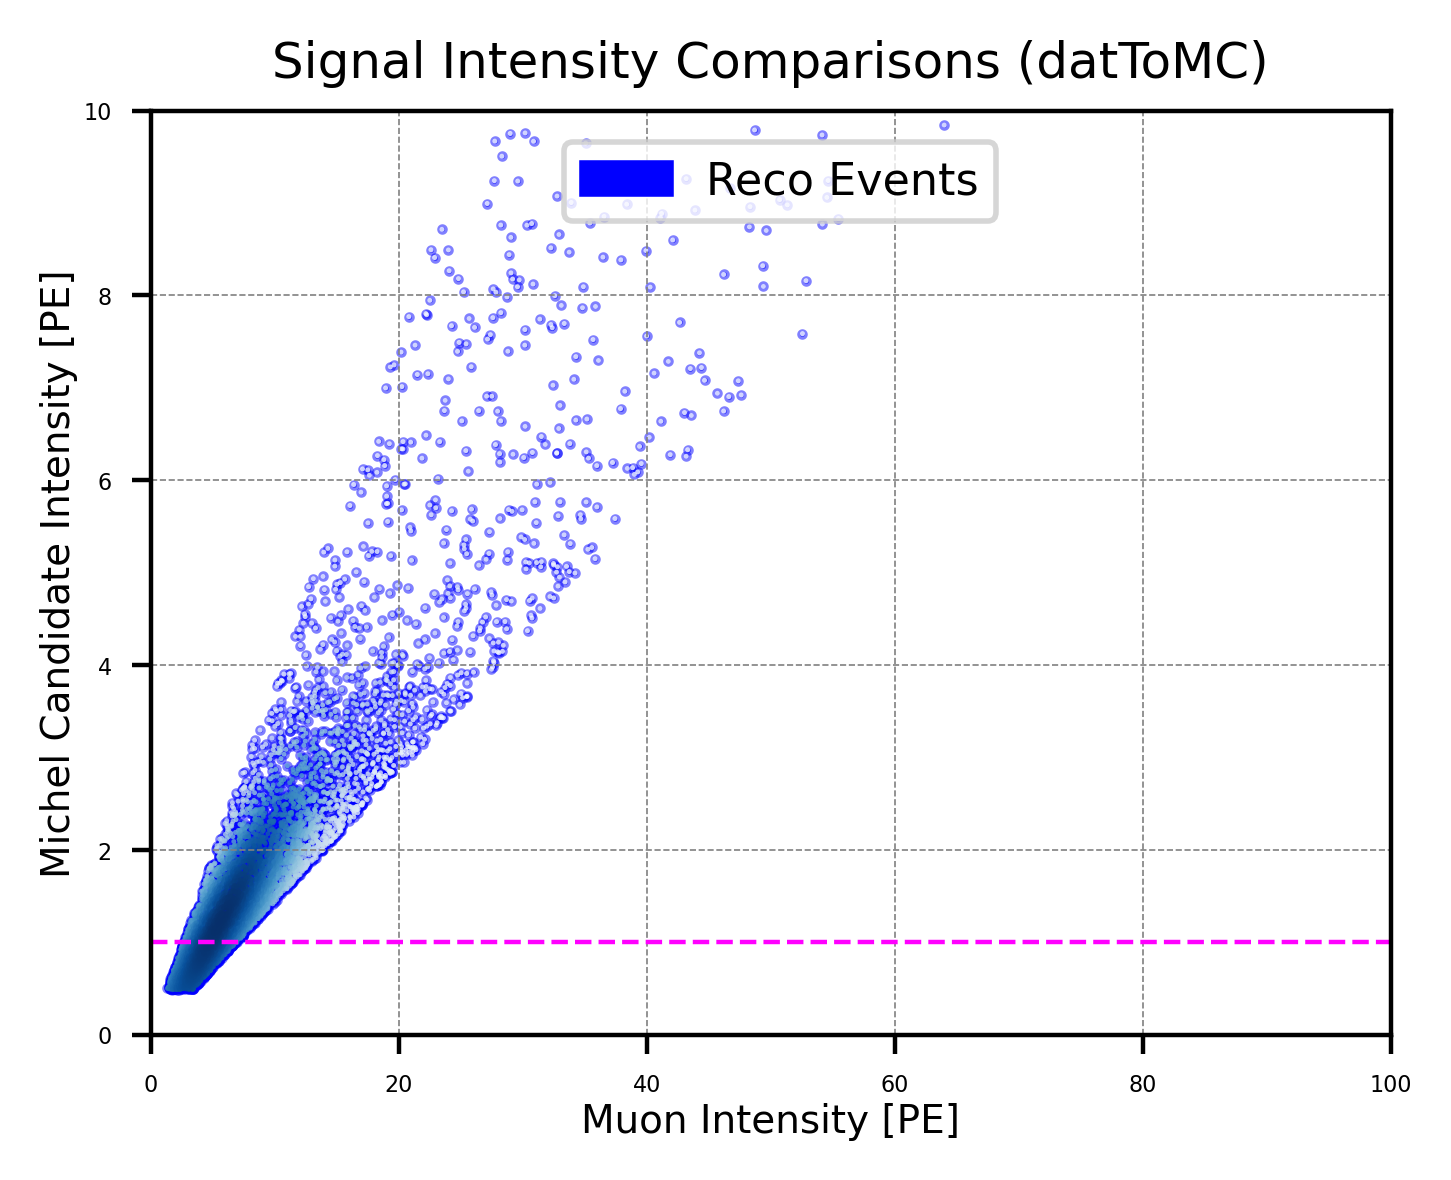


Purify 5----------------------


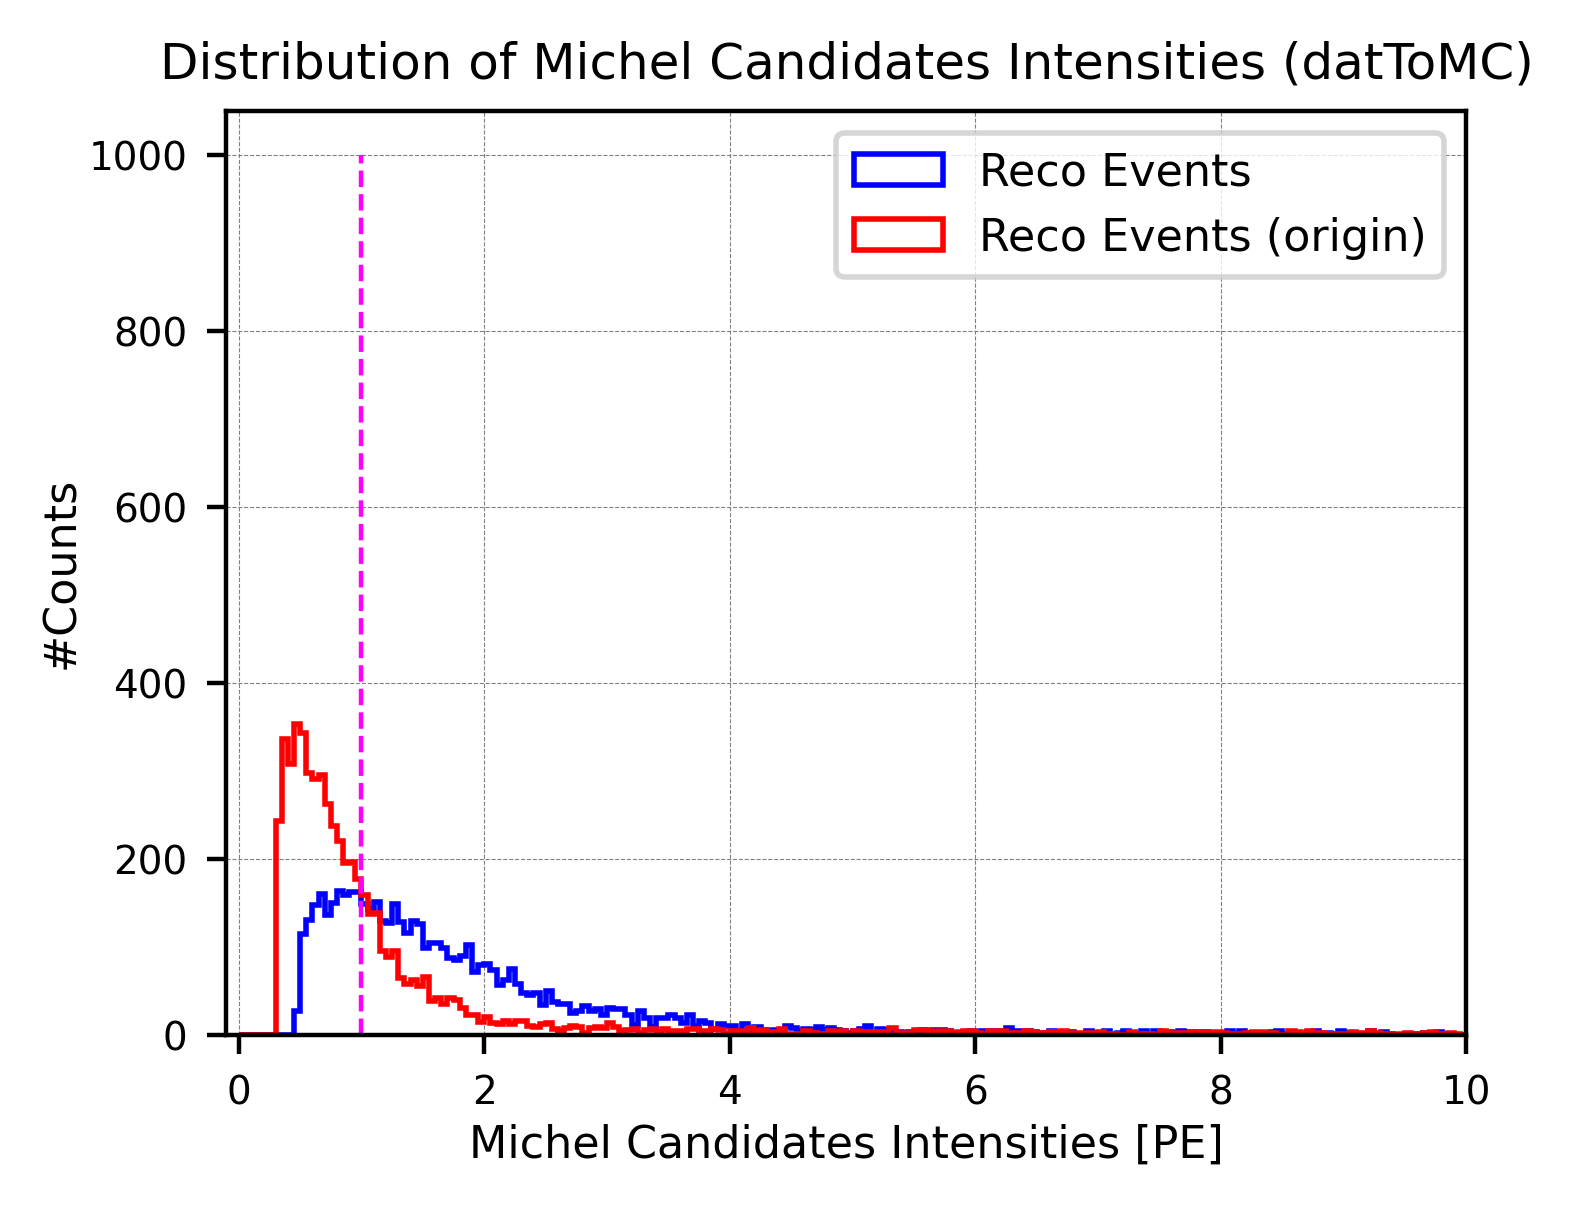

In [15]:
#Michel & Muon Intensities Cut (Cut 5)================================================
print("After cut 4:")

print("# Events: ", len(events_total_purify4))




thre_muInt = 0.3 # mu Int will automatically higher than mi---
thre_miInt = 1.0

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


# filter the actual events
events_total_purify5 = [
    ev for ev in events_total_purify4
    if thre_miInt < michel_dataToMC(ev.michel_intensity) and thre_muInt < ev.muon_intensity
]
#-------------------------------

print("\nMichel Intensity Cut (Cut 5):--------------")

print("Efficiency (cut5 / cut4): ", len(events_total_purify5), "/", len(events_total_purify4),
      "({:.2f}%)".format(len(events_total_purify5)/len(events_total_purify4)*100))








# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================



# For drawing and comparison------------------------------
muInt_tmp = [ev.muon_intensity for ev in events_total_purify4]
miInt_tmp = [ev.michel_intensity for ev in events_total_purify4]

muInt_tmp = np.array(muInt_tmp, dtype=float)
miInt_tmp = np.array(miInt_tmp, dtype=float)

#scaled (dataToMC)
muInt_diff_purify4 = muInt_tmp
miInt_diff_purify4 = michel_dataToMC(miInt_tmp)




plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff_purify4), np.array(miInt_diff_purify4)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 100], [1.0, 1.0], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 100)
plt.ylim(0, 10)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons (datToMC)', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()







#Michel Intensity distribution===================================
print("\nPurify 5----------------------")

#miInt_diff500_purify5 = [ev.michel_intensity for ev in events_diff500_purify5]
#miInt_diff0_purify5 = [ev.michel_intensity for ev in events_diff0_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(miInt_diff_purify4, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events")
plt.hist(miInt_tmp, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Reco Events (origin)")

plt.plot([1.0, 1.0], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 10)
plt.xlabel('Michel Candidates Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities (datToMC)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#### Mu & Michel intensity distributions after Cut 5:

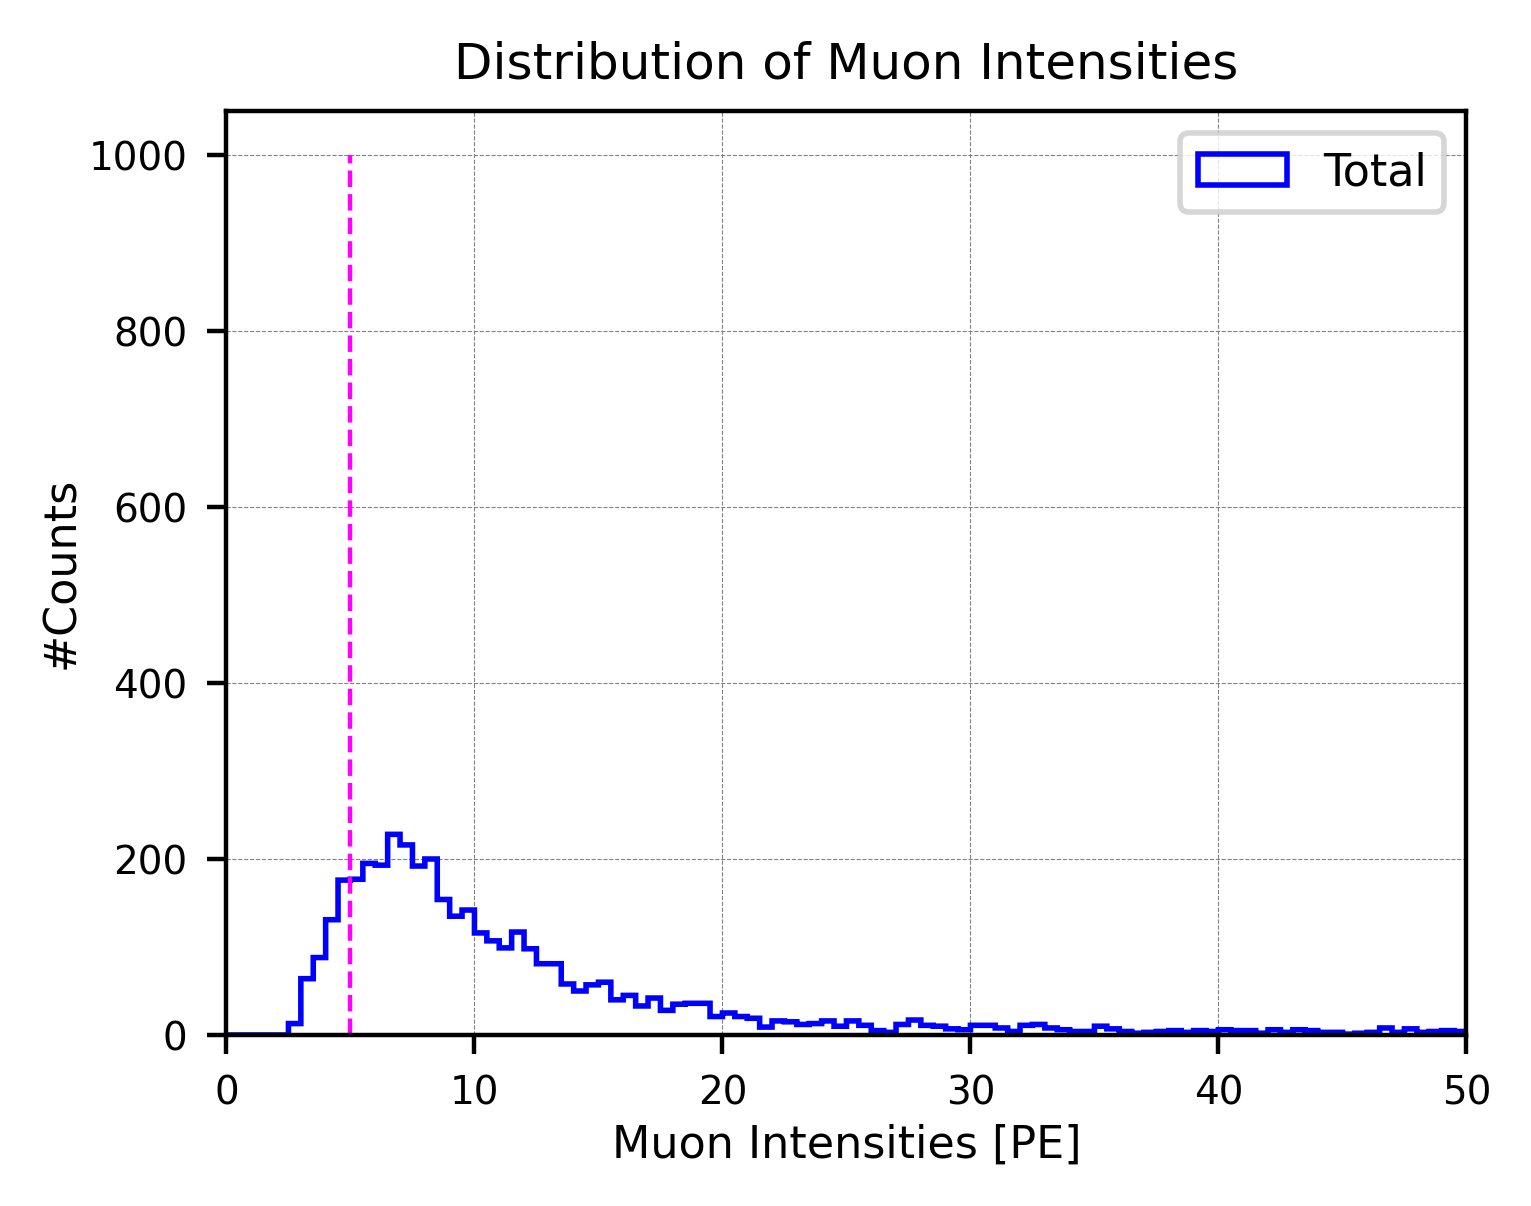

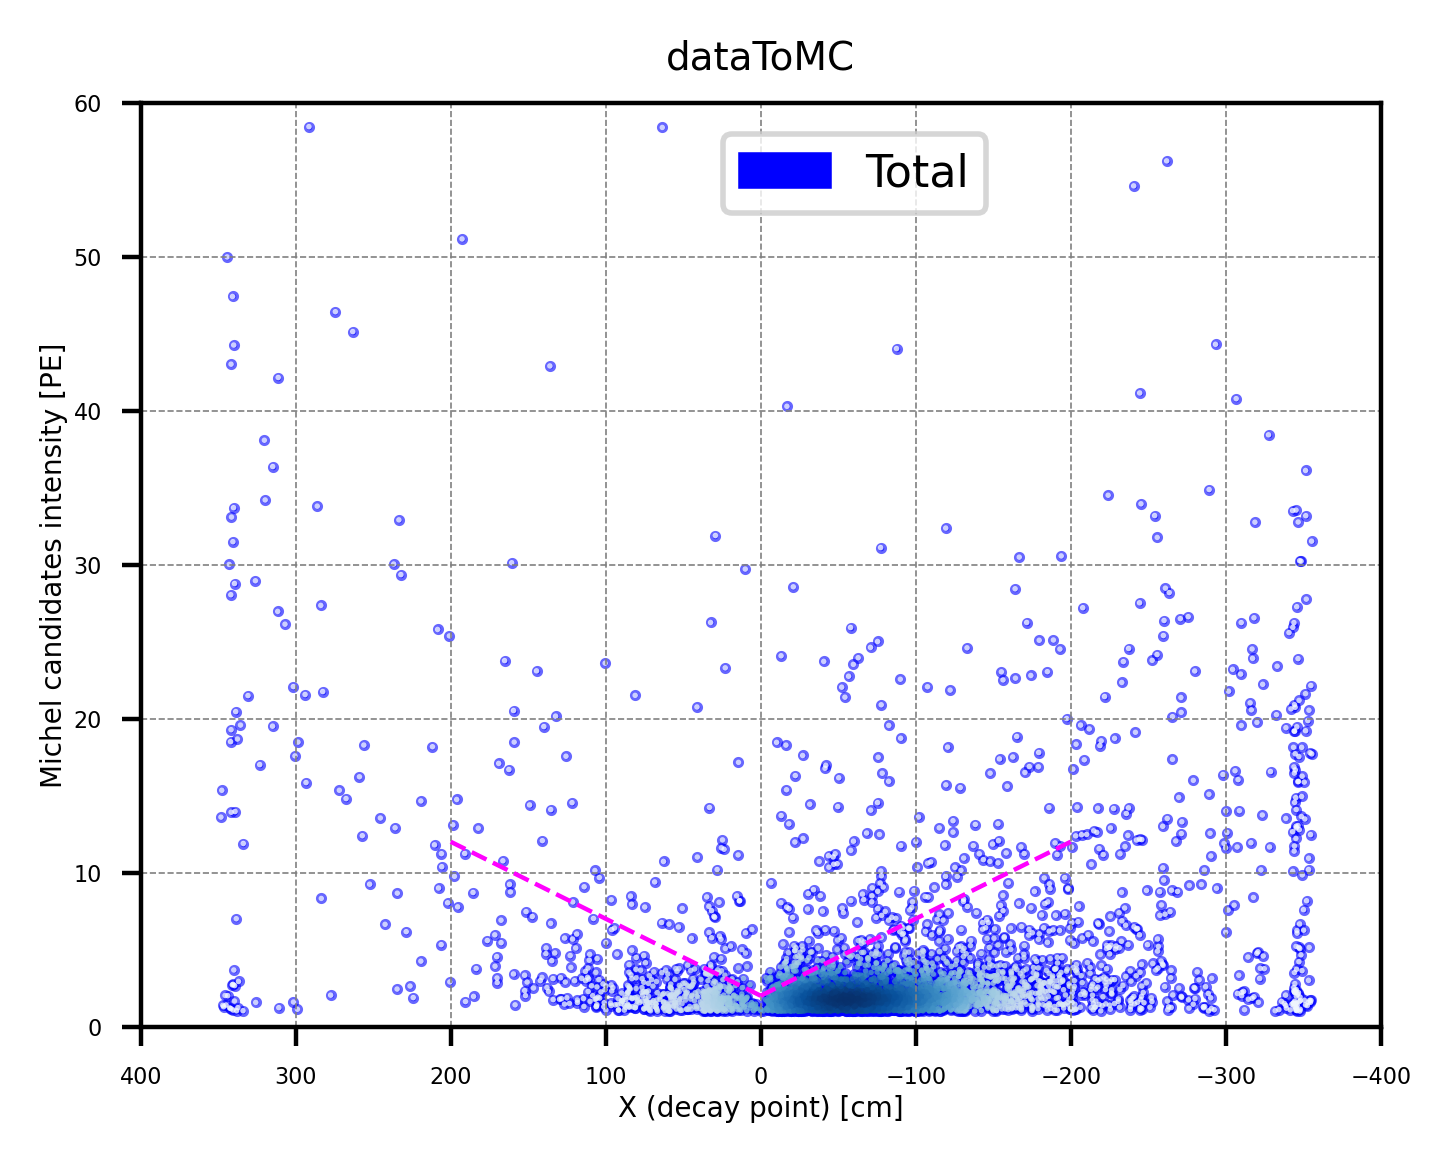

In [16]:
#Muon Intensity distribution===================================

muInt_tmp = [ev.muon_intensity for ev in events_total_purify5]
miInt_tmp = [ev.michel_intensity for ev in events_total_purify5]

muInt_tmp = np.array(muInt_tmp, dtype=float)
miInt_tmp = np.array(miInt_tmp, dtype=float)

#scaled (dataToMC)
muInt_total_purify5 = muInt_tmp
miInt_total_purify5 = michel_dataToMC(miInt_tmp)



plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = 0
range_max = 300
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_total_purify5, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Total")

plt.plot([5, 5], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 50)
plt.xlabel('Muon Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Muon Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 





#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5 = [ev.posX for ev in events_total_purify5]

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5, dtype=float)
y1 = np.array(miInt_total_purify5, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('dataToMC', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()

#### Cut 5': Michel signal VS Distance cut:

After cut 5:---------
#events:  4316

After Cut 5' (Michel vs Distance):--------------
Efficiency (cut5' / cut5):  3985 / 4316 (92.33%)


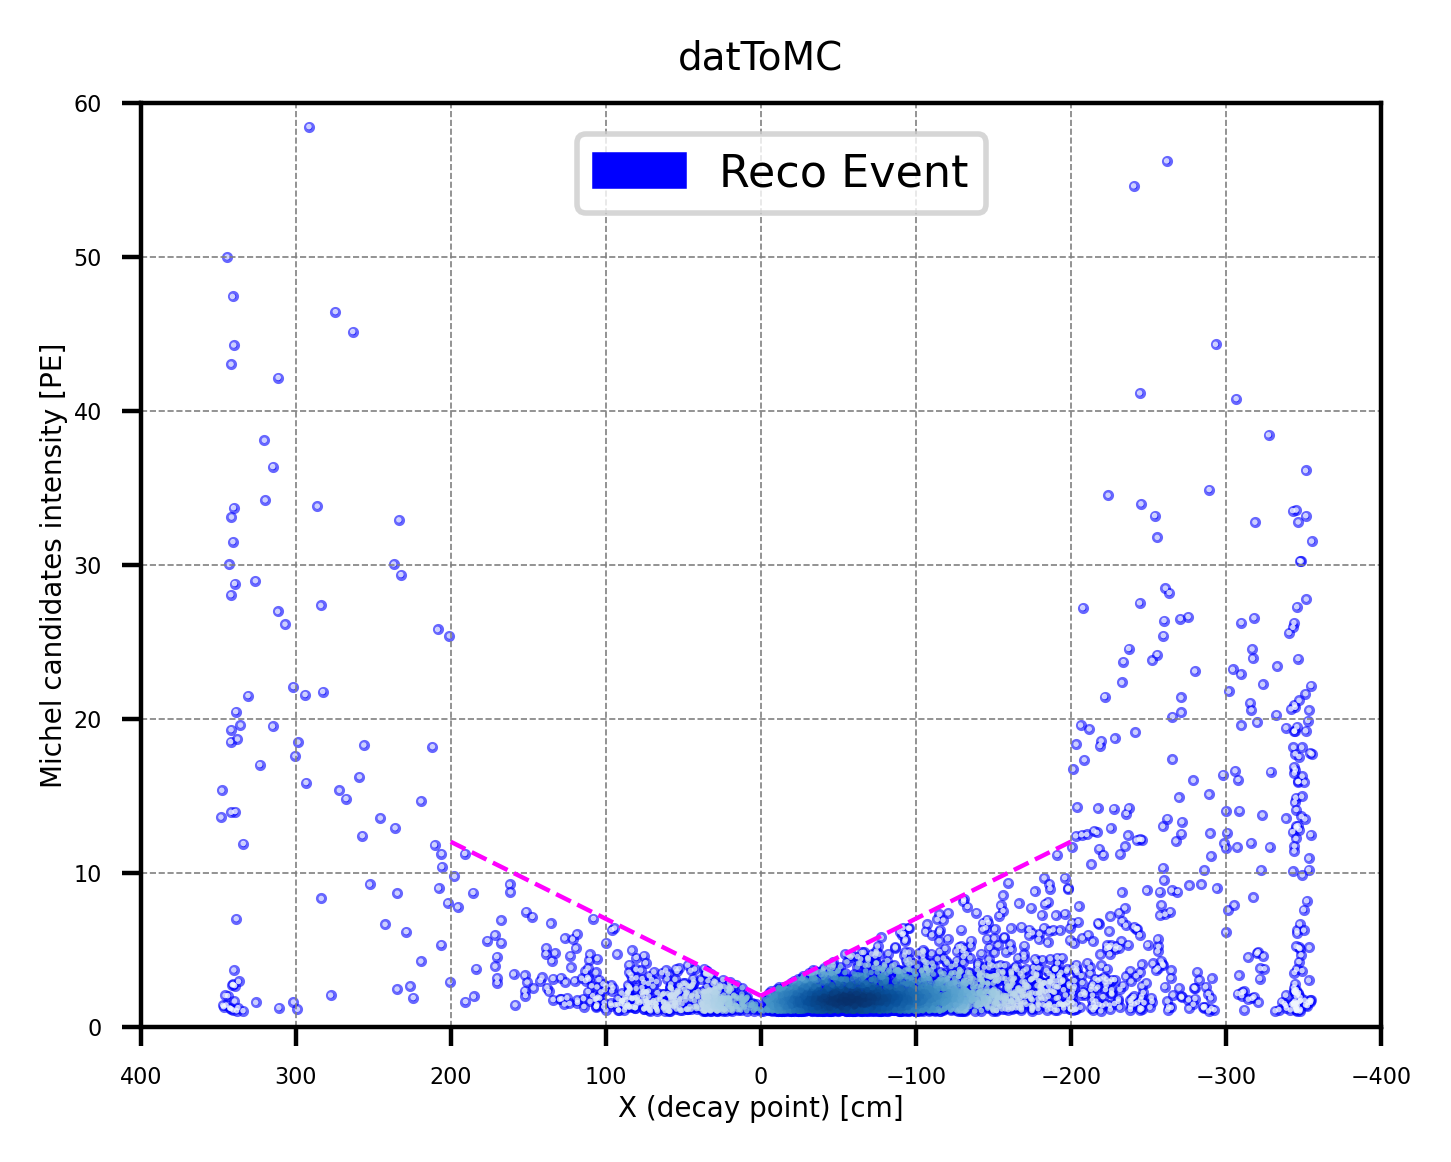

In [17]:
print("After cut 5:---------")

print("#events: ", len(events_total_purify5))



#Michel Peak rise & drop Cut (Cut 5')--------
# --- Define slopes and intercepts for both cuts ---
slope_pos = (7 - 2) / 100.0      # = 0.05
intercept_pos = 2.0

slope_neg = (10 - 0) / (-200 - 0.0)  # = -0.05
# Modified on 2026031: 0.0 to 2.0
intercept_neg = 2.0


#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


def below_line_cut(ev):
    """Return True if event passes both (posX, michel_intensity) cuts."""
    x = ev.posX
#    y = ev.michel_intensity
    y = michel_dataToMC(ev.michel_intensity)#---------------------

    # Region 1: positive side [0, 100]
    if 0 <= x <= 200:
        return y <= intercept_pos + slope_pos * x

    # Region 2: negative side [-200, 0]
    elif -200 <= x <= 0:
        return y <= intercept_neg + slope_neg * x

    # Outside both ranges: no cut
    else:
        return True

# --- Apply the geometric cut to both event classes ---
events_total_purify5P = [ev for ev in events_total_purify5 if below_line_cut(ev)]
#-------------------------------





print("\nAfter Cut 5' (Michel vs Distance):--------------")

print("Efficiency (cut5' / cut5): ", len(events_total_purify5P), "/", len(events_total_purify5),
      "({:.2f}%)".format(len(events_total_purify5P)/len(events_total_purify5)*100))






#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5P = [ev.posX for ev in events_total_purify5P]
miInt_tmp = [ev.michel_intensity for ev in events_total_purify5P]

miInt_tmp = np.array(miInt_tmp, dtype=float)

#scaled (dataToMC)
miInt_total_purify5P = michel_dataToMC(miInt_tmp)

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5P, dtype=float)
y1 = np.array(miInt_total_purify5P, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('datToMC', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Reco Event")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#### Cut 6: Michel peak rise and drop slope: 

After cut 5':---------
#event    :  3985

Michel Peak Rise Drop Slope (Cut 6):--------------
Efficiency (cut6 / cut5'):  3010 / 3985 (75.53%)


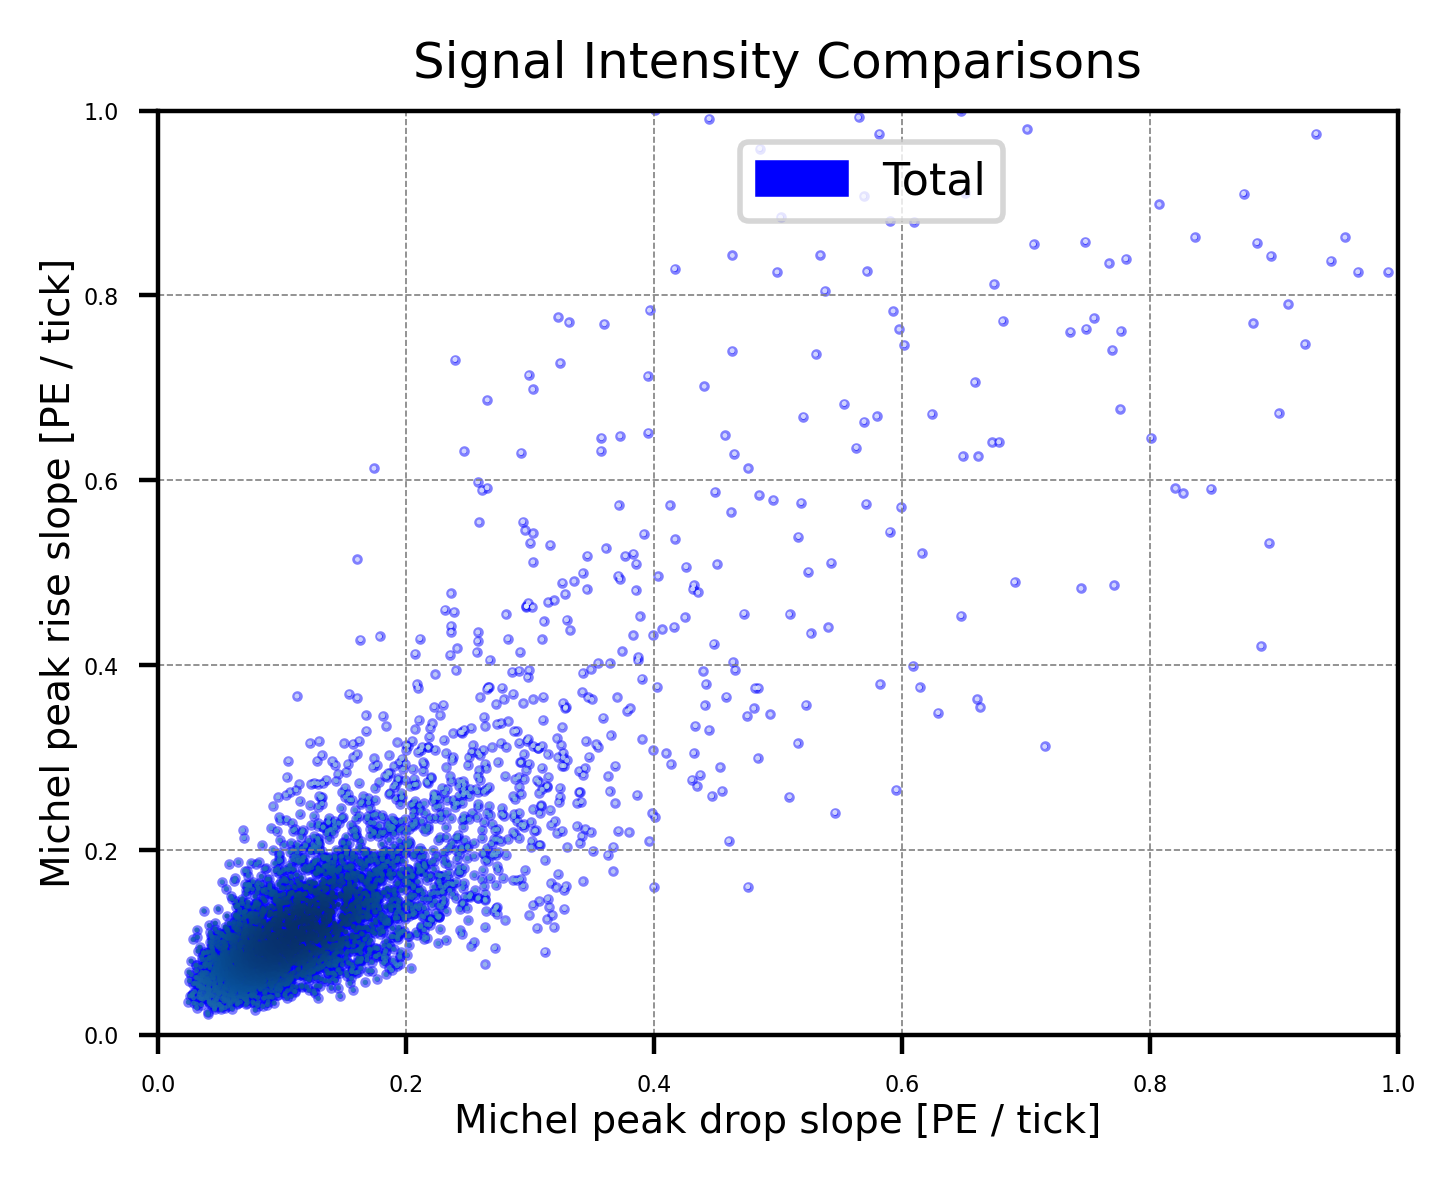

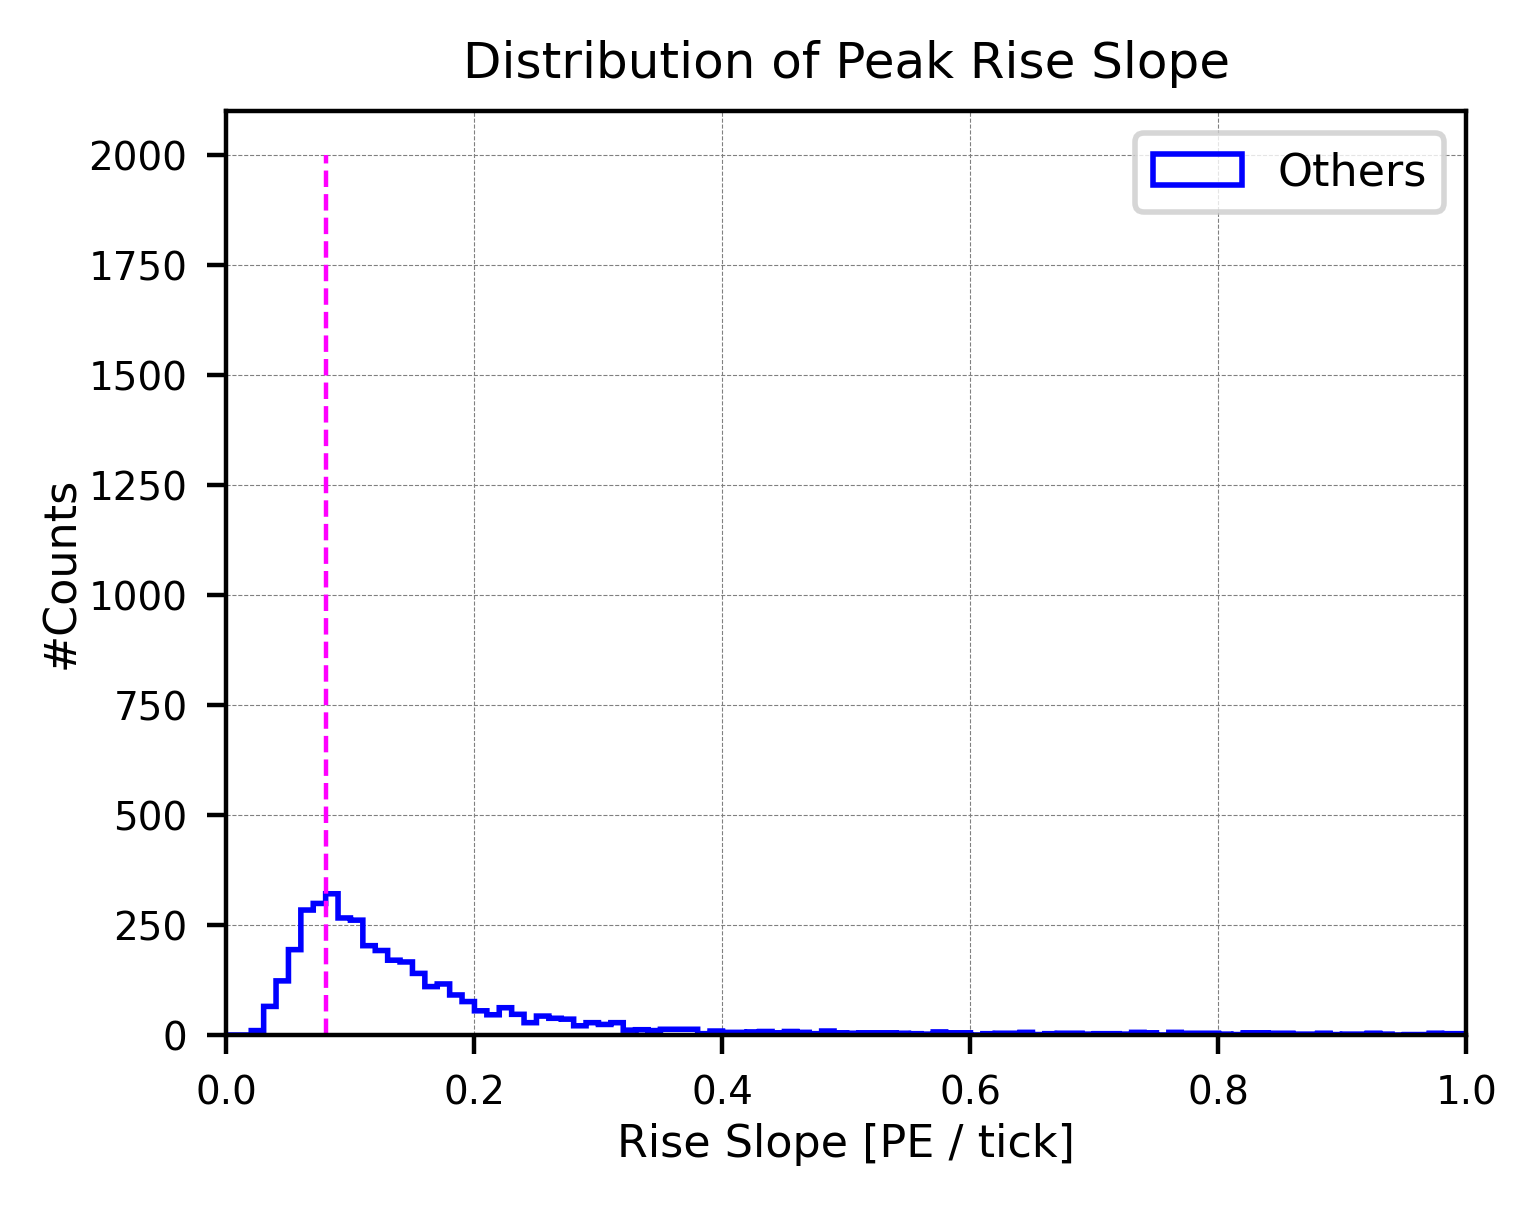

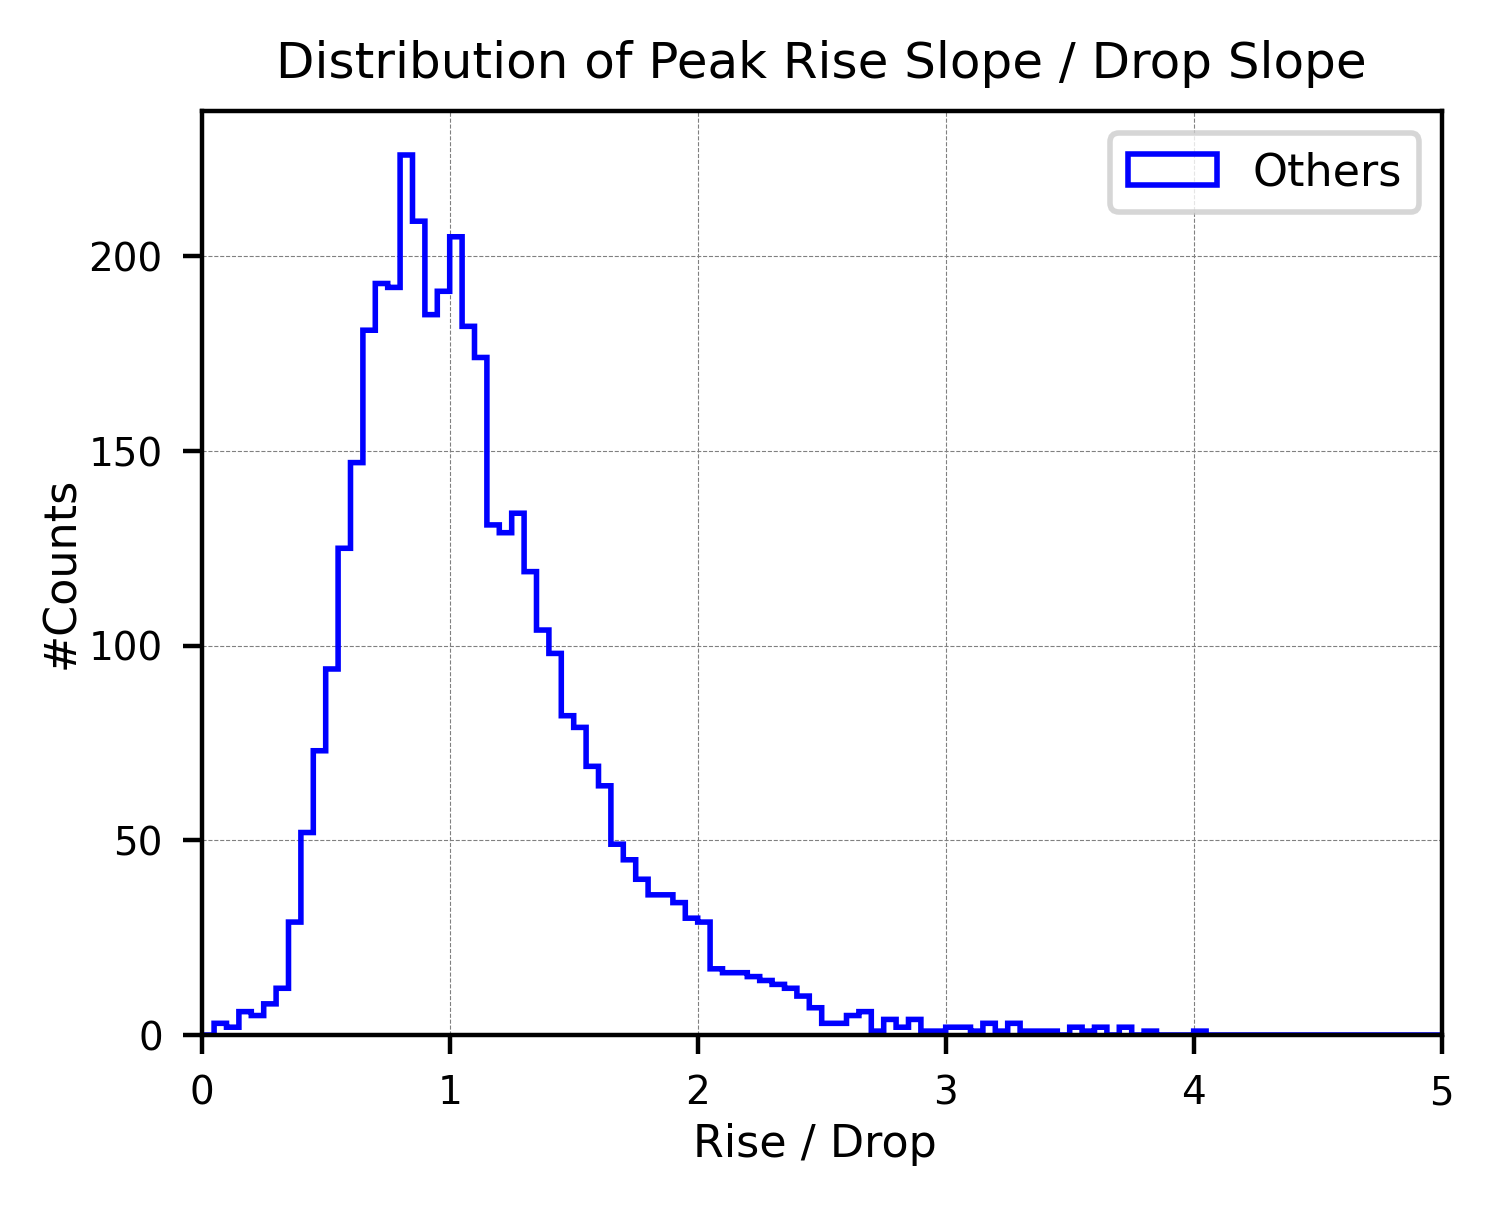

In [18]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 5':---------")
print("#event    : ", len(events_total_purify5P))


#Shu: slope might be unchanged even though the intensity is scaled (peak expansion also modified?)

rise_total_purity5P = [ev.michel_rise for ev in events_total_purify5P]
drop_total_purity5P = [ev.michel_drop for ev in events_total_purify5P]

ratios_total_purity5P = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_total_purity5P, drop_total_purity5P)
]



thre_rise = 0.08 # mu Int will automatically higher than mi---

#Slope calculation is updated based on miInt update; 20251207---

# filter the actual events
events_total_purify6 = [
    ev for ev in events_total_purify5P
    if thre_rise < ev.michel_rise 
]
#-------------------------------



print("\nMichel Peak Rise Drop Slope (Cut 6):--------------")

print("Efficiency (cut6 / cut5'): ", len(events_total_purify6), "/", len(events_total_purify5P),
      "({:.2f}%)".format(len(events_total_purify6)/len(events_total_purify5P)*100))








# ==========================================================
# Michel Rise VS Michel Drop
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(drop_total_purity5P), np.array(rise_total_purity5P)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")


#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Michel peak drop slope [PE / tick]', labelpad=1, fontsize=7)
plt.ylabel('Michel peak rise slope [PE / tick]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#Michel Rise Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(rise_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.08, 0.08], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 1.0)
plt.xlabel('Rise Slope [PE / tick]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 400)
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#Michel Rise & Drop Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
plt.hist(ratios_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")


plt.xlim(0, 5)
plt.xlabel('Rise / Drop ', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope / Drop Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 




### Cut 7: 2nd 3rd peak intensity Ratio cut

After cut 6:---------
#event    :  3010

Third / Second peak intensity (Cut 7):--------------
Efficiency (cut7 / cut6):  2336 / 3010 (77.61%)


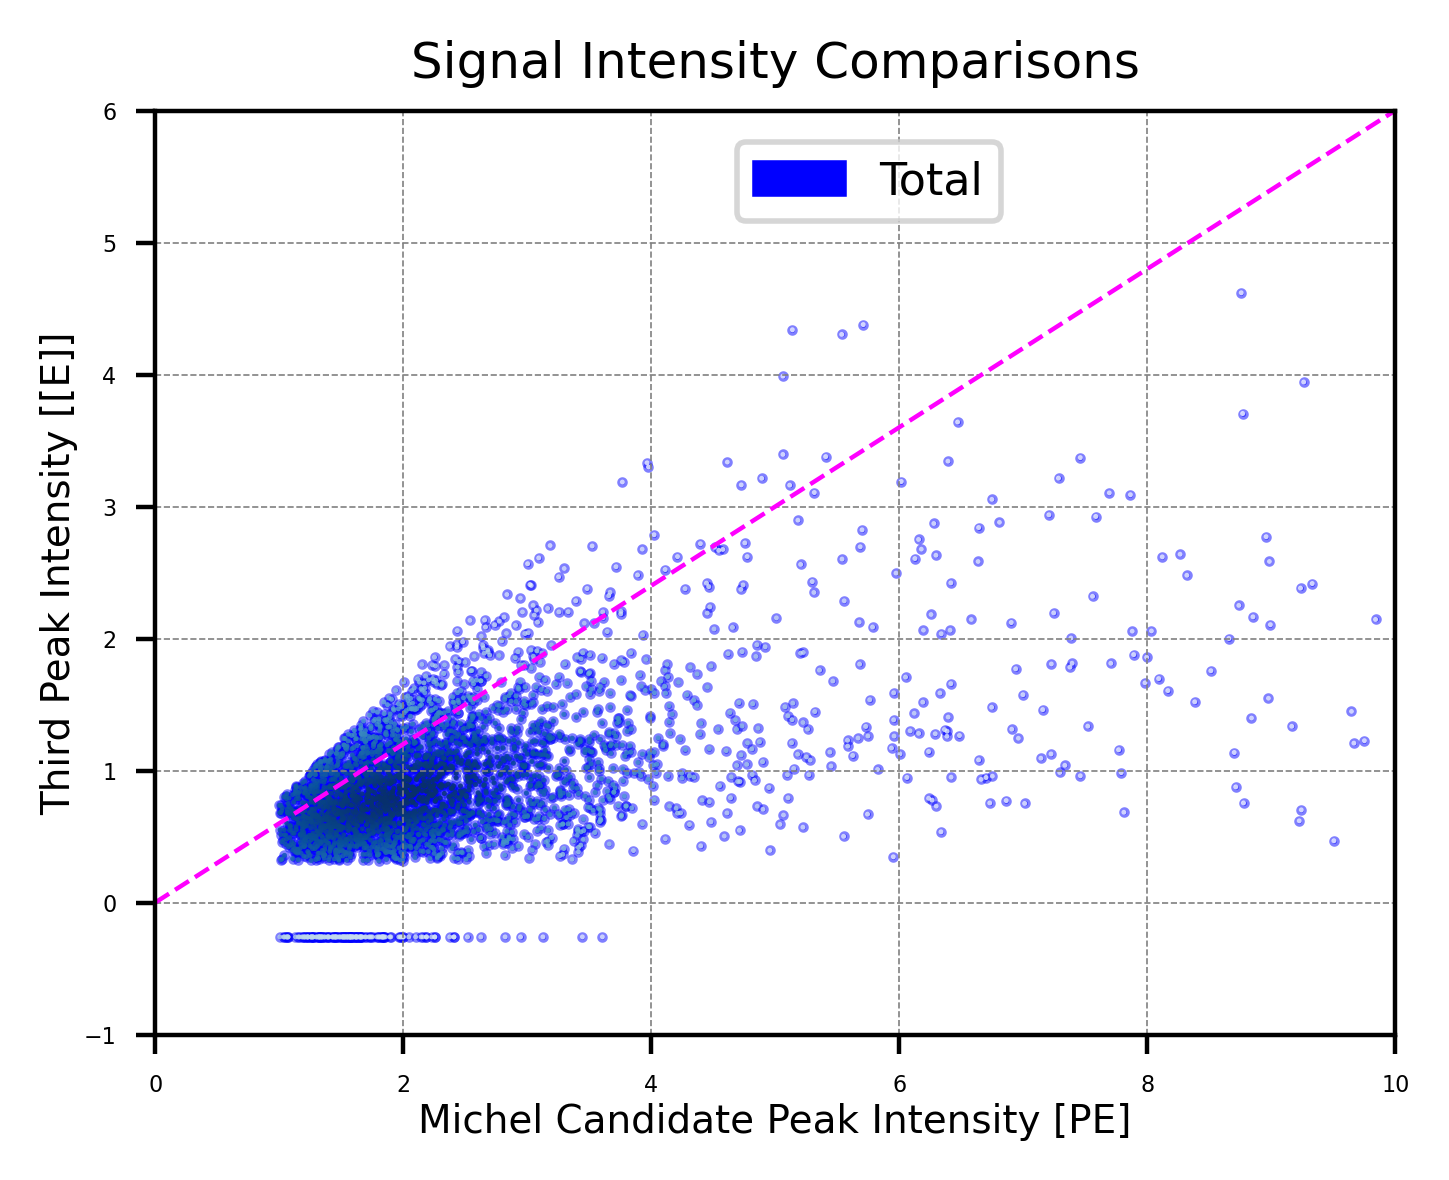

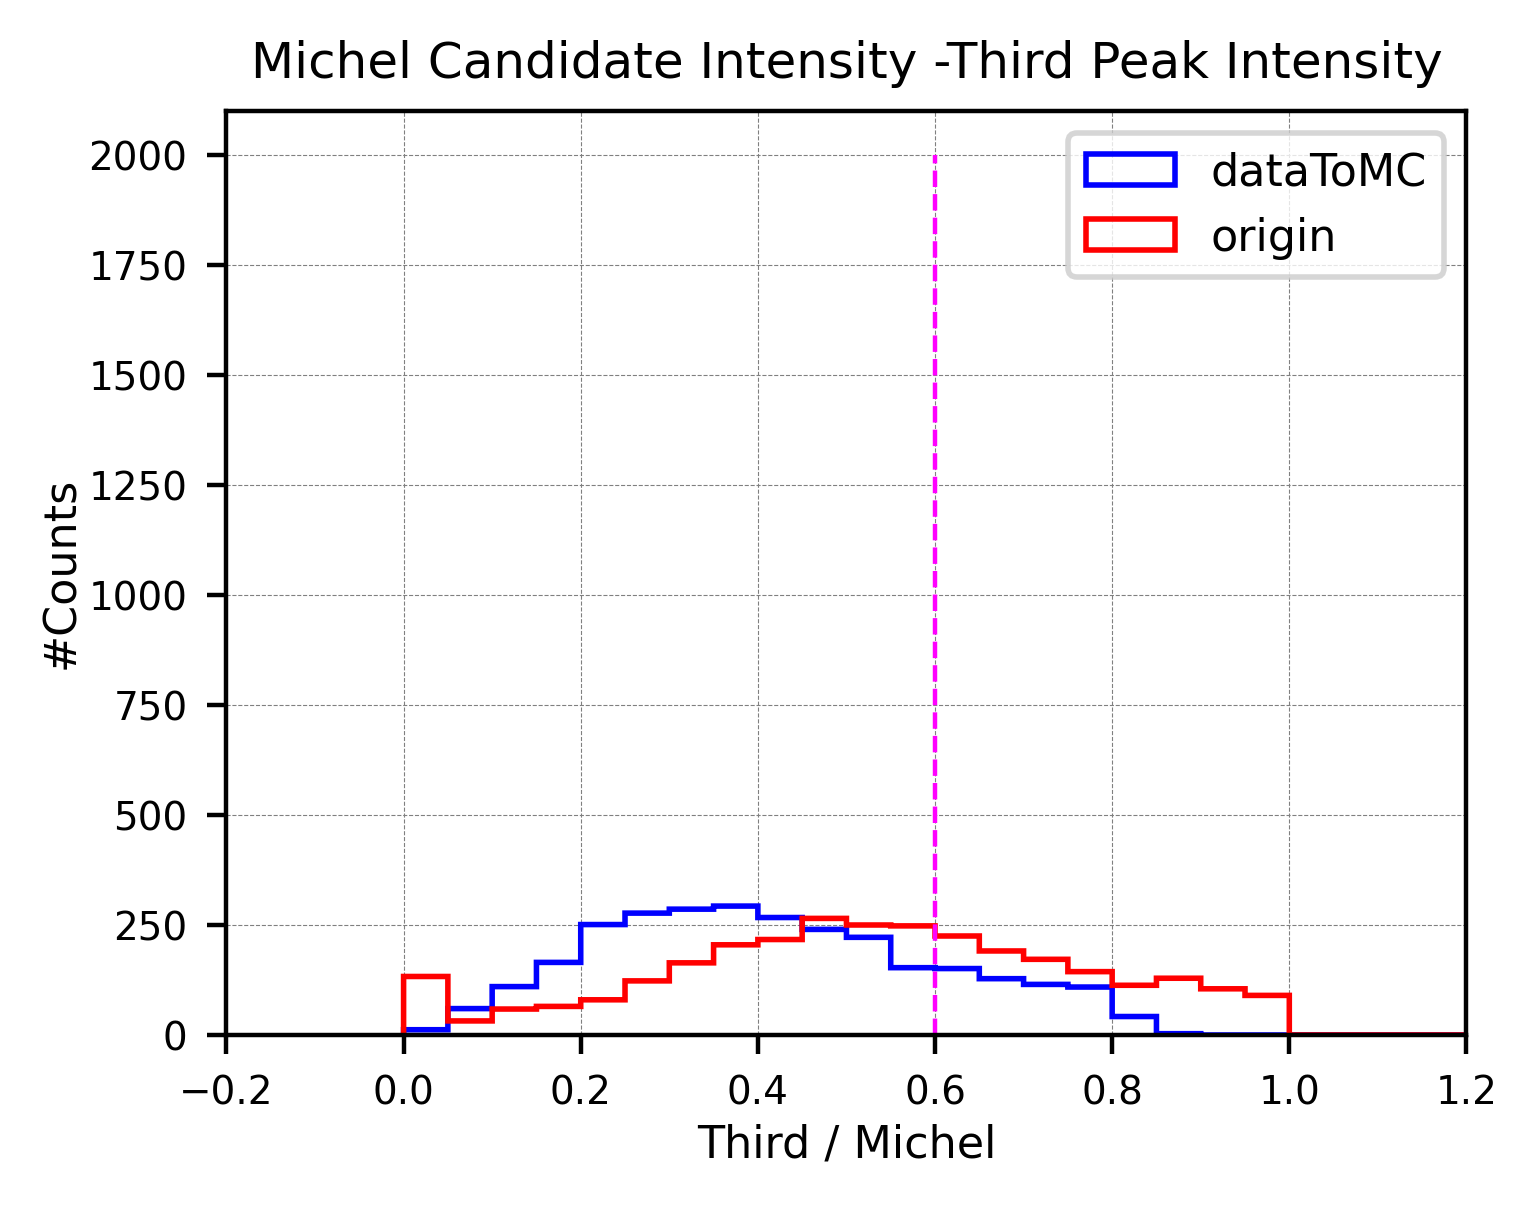

In [19]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 6:---------")

print("#event    : ", len(events_total_purify6))



miInt_tmp = [ev.michel_intensity for ev in events_total_purify6]
miInt_tmp = np.array(miInt_tmp, dtype=float)
miInt_total_purity6 = michel_dataToMC(miInt_tmp)

third_tmp = [ev.third_intensity for ev in events_total_purify6]
third_tmp = np.array(third_tmp, dtype=float)
thInt_total_purity6 = third_dataToMC(third_tmp)


# Element-by-element ratio (thInt / miInt)
ratio_total_purity6 = [th / mi for th, mi in zip(thInt_total_purity6, miInt_total_purity6)]
ratio_initial_purity6 = [th / mi for th, mi in zip(third_tmp, miInt_tmp)]

thre1 = 0.0
thre2 = 0.6

# filter the actual events

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


events_total_purify7 = [
    ev for ev in events_total_purify6
#    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / ev.michel_intensity < thre2
    if ev.michel_intensity != 0 and thre1 < third_dataToMC(ev.third_intensity) / michel_dataToMC(ev.michel_intensity) < thre2    
]
#-------------------------------


print("\nThird / Second peak intensity (Cut 7):--------------")
print("Efficiency (cut7 / cut6): ", len(events_total_purify7), "/", len(events_total_purify6),
      "({:.2f}%)".format(len(events_total_purify7)/len(events_total_purify6)*100))









# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x2, y2 = np.array(miInt_total_purity6), np.array(thInt_total_purity6)
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 100], [0, 60], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Third / Michel Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_total_purity6, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="dataToMC")
plt.hist(ratio_initial_purity6, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="origin")

plt.plot([0.6, 0.6], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.2, 1.2)
plt.xlabel('Third / Michel', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 

### Cut 8: Third second peak intensity diff cut


After Cut 7:--------------
#event   :  2336

Michel 3rd Peaks intensity Diff (Cut 8):--------------
Efficiency (cut8 / cut7):  2182 / 2336 (93.41%)


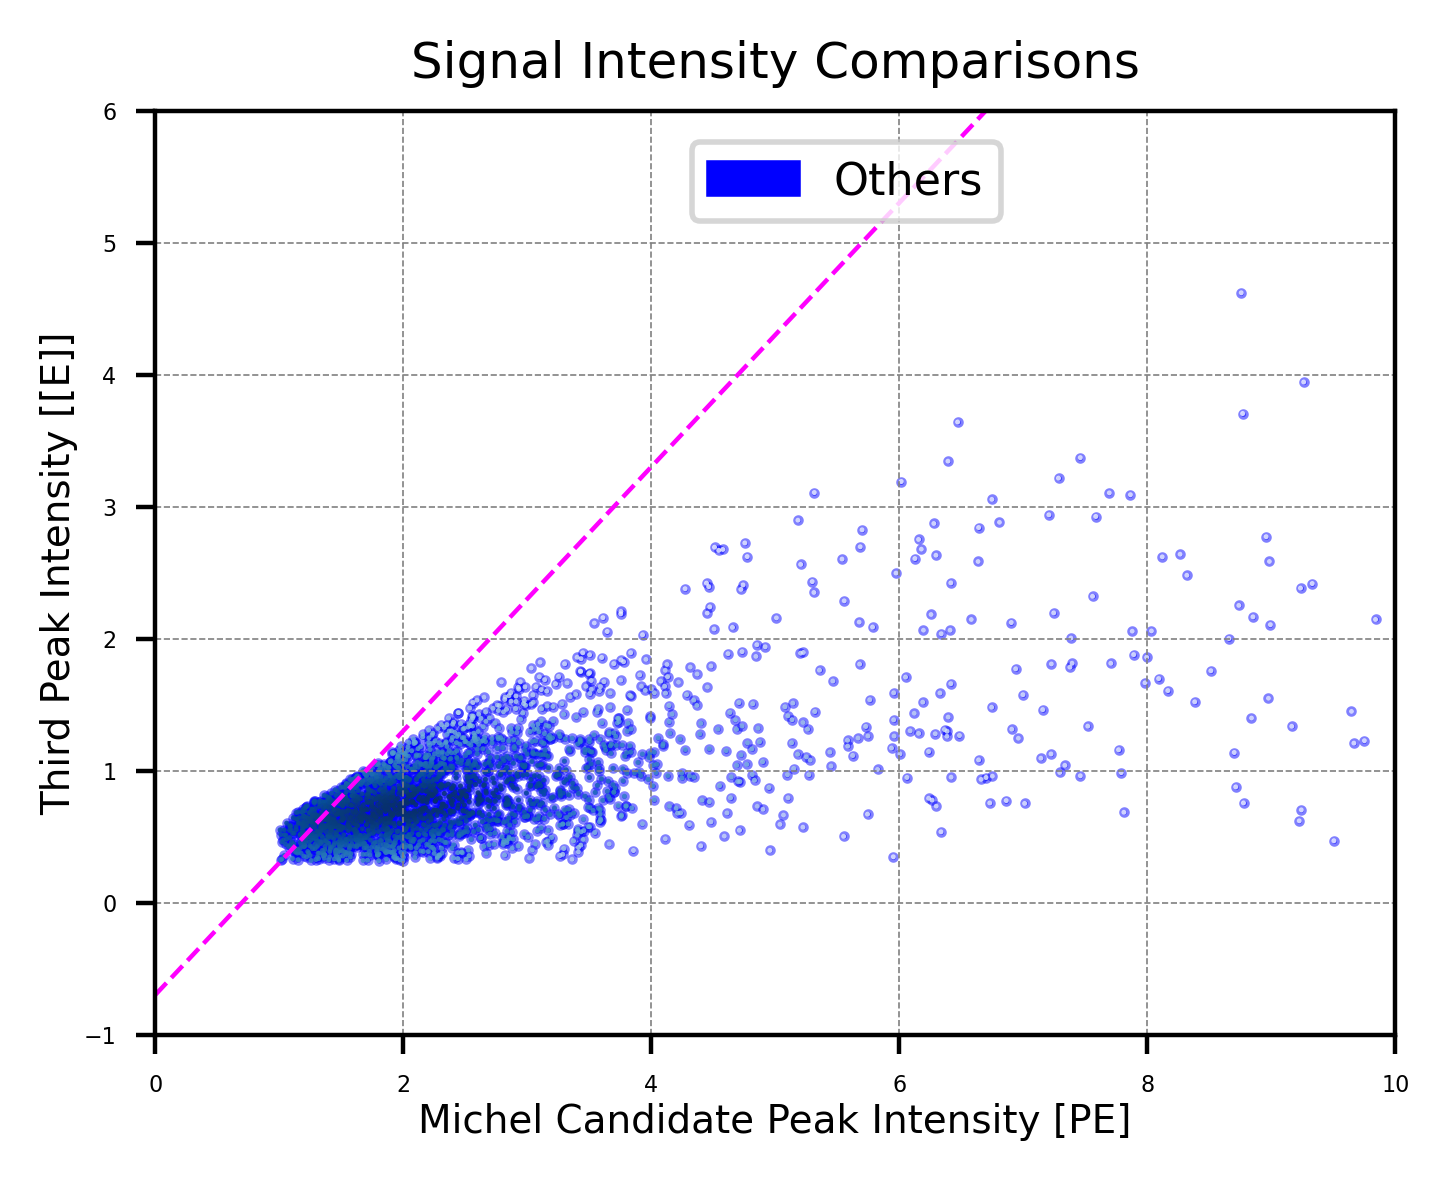

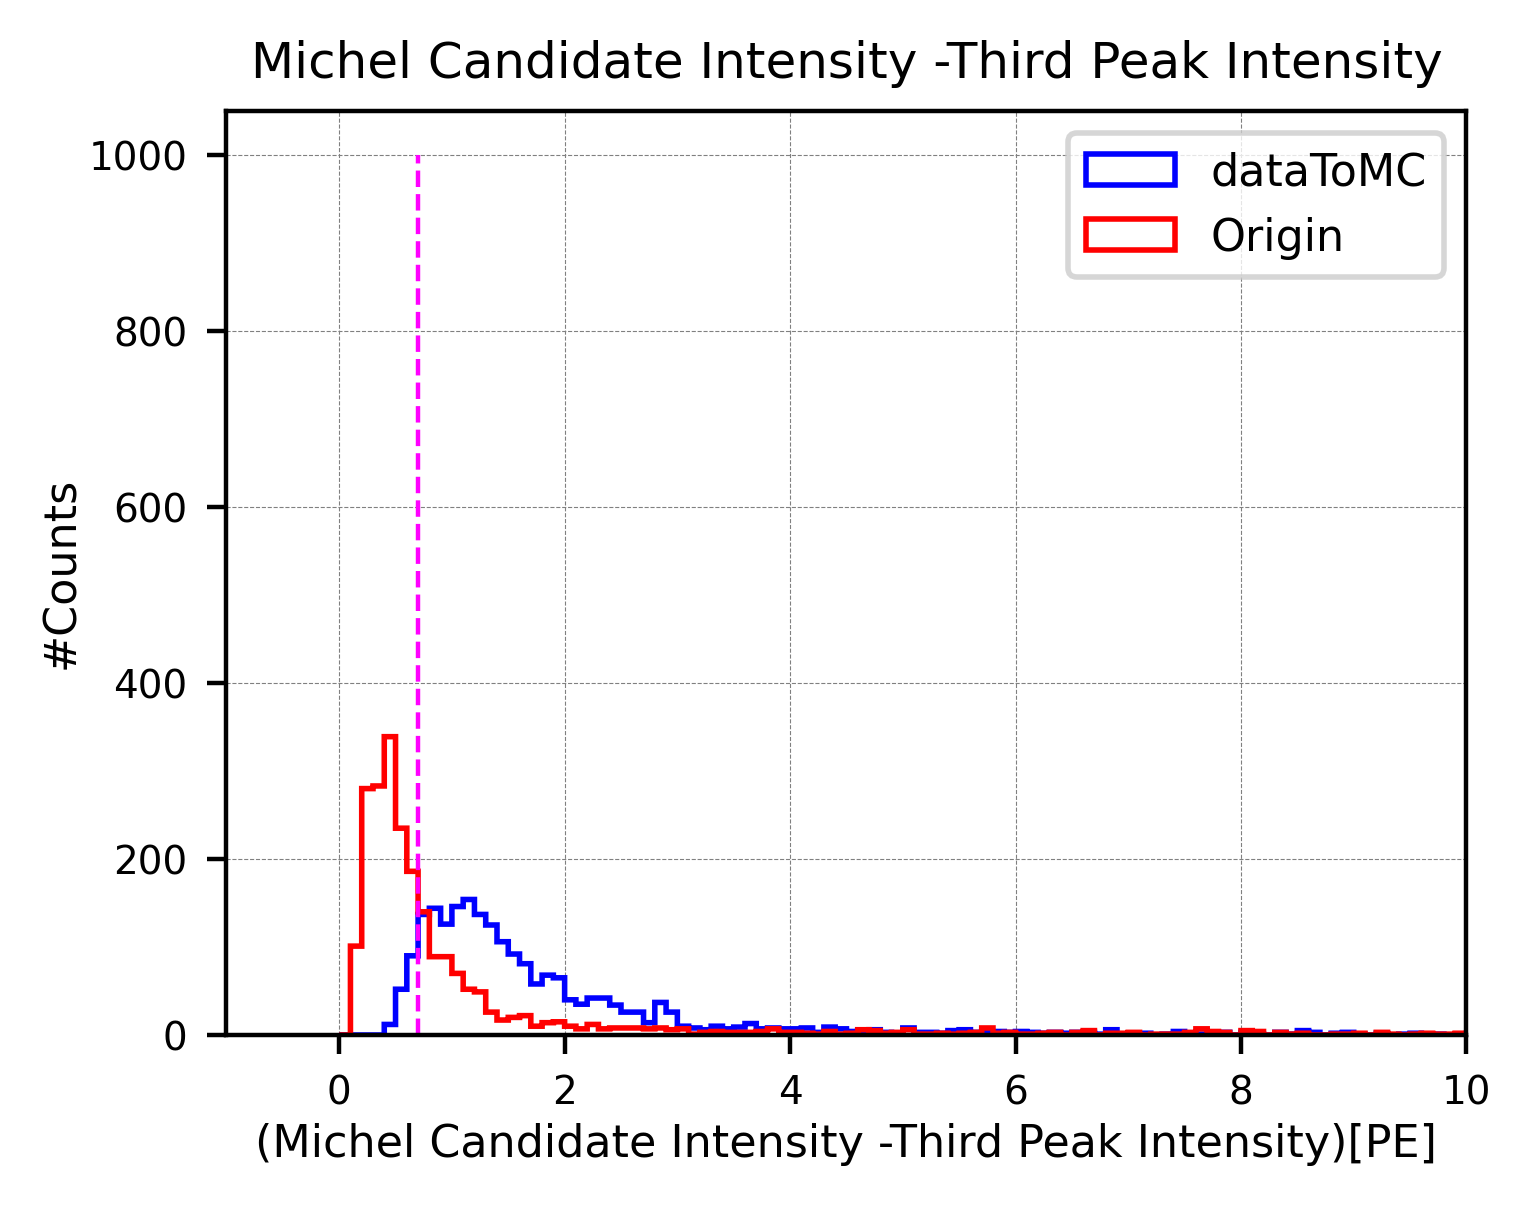

In [20]:
print("\nAfter Cut 7:--------------")

print("#event   : ", len(events_total_purify7))

miInt_tmp = [ev.michel_intensity for ev in events_total_purify7]
miInt_tmp = np.array(miInt_tmp, dtype=float)
miInt_total_purity7 = michel_dataToMC(miInt_tmp)

third_tmp = [ev.third_intensity for ev in events_total_purify7]
third_tmp = np.array(third_tmp, dtype=float)
thInt_total_purity7 = third_dataToMC(third_tmp)



# Element-by-element difference (thInt - miInt)
subtract_total_purity7 = [mi - th for th, mi in zip(thInt_total_purity7, miInt_total_purity7)]
subtract_initial_purity7 = [mi - th for th, mi in zip(third_tmp, miInt_tmp)]

thre_diff = 0.7


# filter the actual events
events_total_purify8 = [
    ev for ev in events_total_purify7
#    if thre_diff <  (ev.michel_intensity - ev.third_intensity)
    if thre_diff <  (michel_dataToMC(ev.michel_intensity) - third_dataToMC(ev.third_intensity))    
]
#-------------------------------


print("\nMichel 3rd Peaks intensity Diff (Cut 8):--------------")

print("Efficiency (cut8 / cut7): ", len(events_total_purify8), "/", len(events_total_purify7),
      "({:.2f}%)".format(len(events_total_purify8)/len(events_total_purify7)*100))










# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(miInt_total_purity7), np.array(thInt_total_purity7)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

plt.plot([0, 10], [-0.7, 9.3], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Others")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()









#(Michel Candidate Intensity -Third Peak Intensity) Distributions====================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(subtract_total_purity7, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="dataToMC")
plt.hist(subtract_initial_purity7, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Origin")

plt.plot([0.7, 0.7], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-1, 10)
plt.xlabel('(Michel Candidate Intensity -Third Peak Intensity)[PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  

### Cut 9: Space Cut along drift direction


After Cut 8:--------------
Event    :  2182

Drift Direction Cut (Cut 9):--------------
Efficiency (cut9 / cut8):  1818 / 2182 (83.32%)

Decay points distribution: 


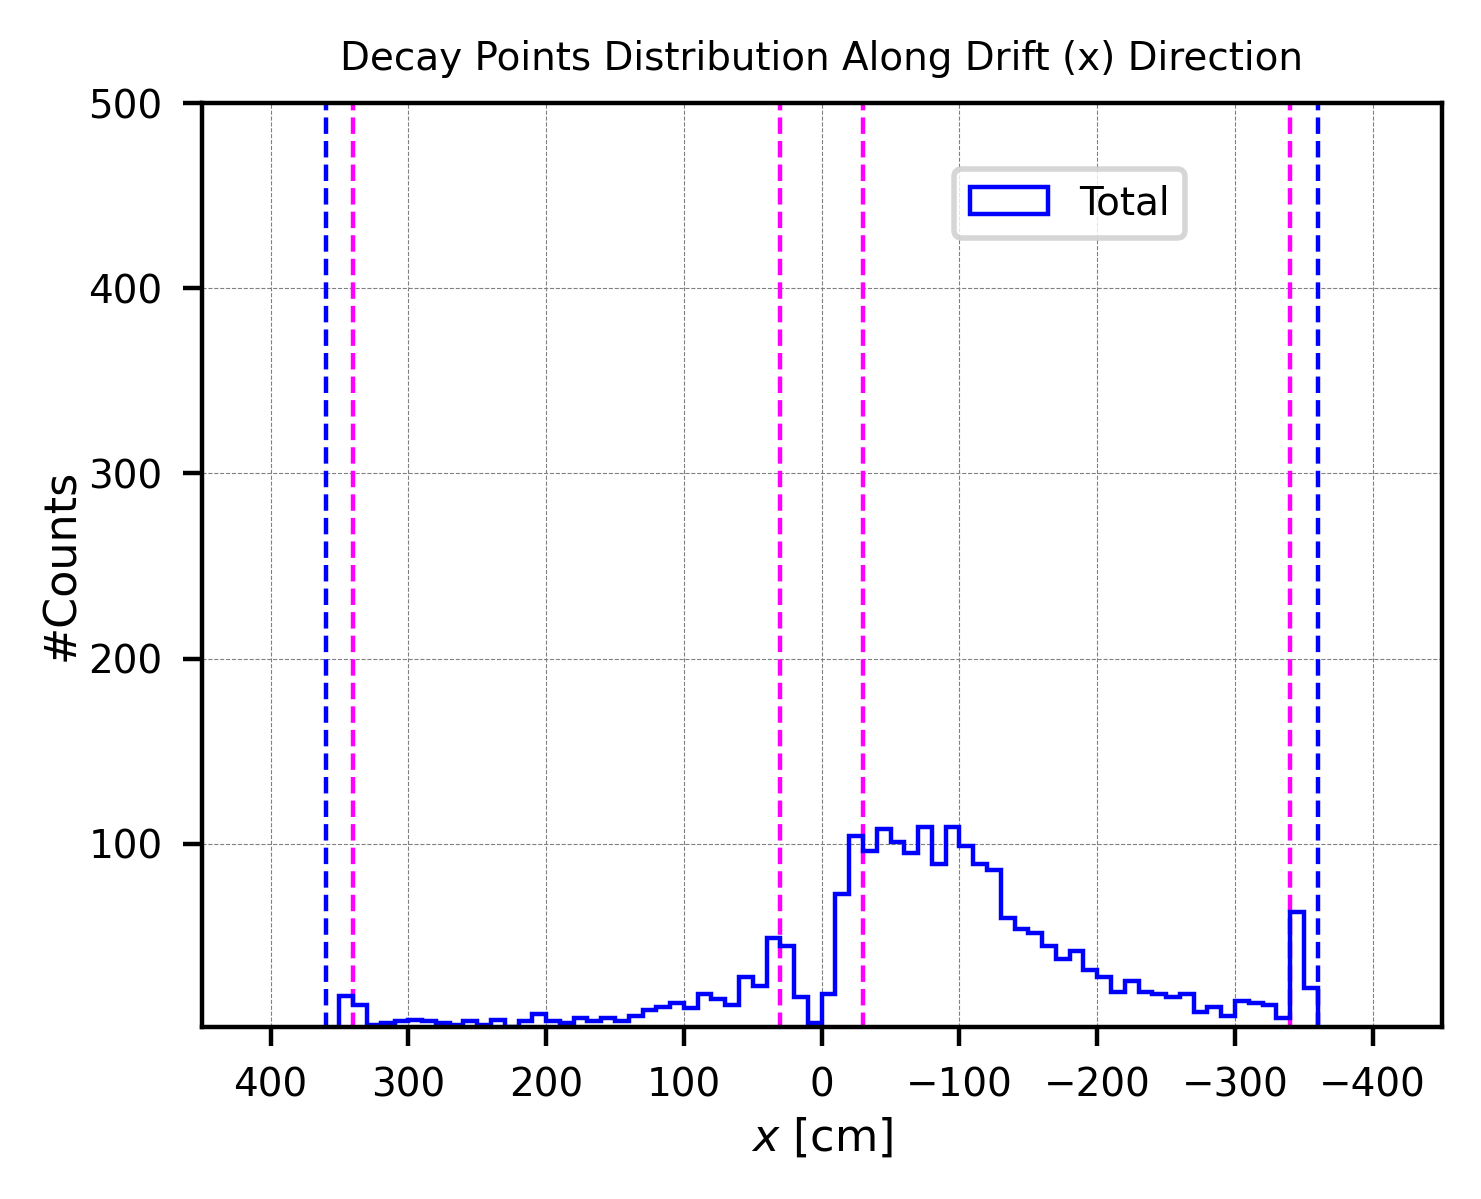

In [21]:
print("\nAfter Cut 8:--------------")

print("Event    : ", len(events_total_purify8))






#Shu (20260311): manually new threshold for beam side
posX_cut1 = 30
posX_cut2 = 340
negX_cut1 = -30
negX_cut2 = -340

# filter the actual events
events_total_purify9 = [
    ev for ev in events_total_purify8
    if posX_cut1 < ev.posX < posX_cut2 or negX_cut2 < ev.posX < negX_cut1
]


#-------------------------------


print("\nDrift Direction Cut (Cut 9):--------------")

print("Efficiency (cut9 / cut8): ", len(events_total_purify9), "/", len(events_total_purify8),
      "({:.2f}%)".format(len(events_total_purify9)/len(events_total_purify8)*100))










posX_total_purify8 = [ev.posX for ev in events_total_purify8]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Cut line------
plt.plot([posX_cut1, posX_cut1], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([posX_cut2, posX_cut2], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([negX_cut1, negX_cut1], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([negX_cut2, negX_cut2], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify8, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 500)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




<br />

#### Single Event Inspection:

In [22]:
# "Signal"
for ev in events_total_purify9:
    if ev.reco_lifetime >10000:
        print(ev)



PdsEventNew(muon_time=60, michel_time=1007, muon_intensity=15.3692, michel_intensity=2.10964, third_intensity=0.63171, posX=-181.718, posY=50.1342, posZ=343.946, eventID=108569, trackID=0, date='28891BKG', michel_score=0.0, michel_hits=0, reco_lifetime=15152, michel_rise=0.2097434782608696, michel_drop=0.46046428571428566)
PdsEventNew(muon_time=60, michel_time=965, muon_intensity=20.2006, michel_intensity=3.53571, third_intensity=1.18165, posX=-231.226, posY=199.102, posZ=232.363, eventID=114293, trackID=4, date='28891BKG', michel_score=0.0, michel_hits=0, reco_lifetime=14480, michel_rise=0.5707573529411764, michel_drop=0.5992339285714287)
PdsEventNew(muon_time=62, michel_time=884, muon_intensity=167.892, michel_intensity=20.8498, third_intensity=1.68474, posX=-293.467, posY=463.722, posZ=234.341, eventID=120108, trackID=3, date='28891BKG', michel_score=0.00365981, michel_hits=2, reco_lifetime=13152, michel_rise=2.865261904761905, michel_drop=1.2918625)
PdsEventNew(muon_time=61, michel

<br />
<br />

#### Features of final dataset (after purification 9):


Decay points distribution: 


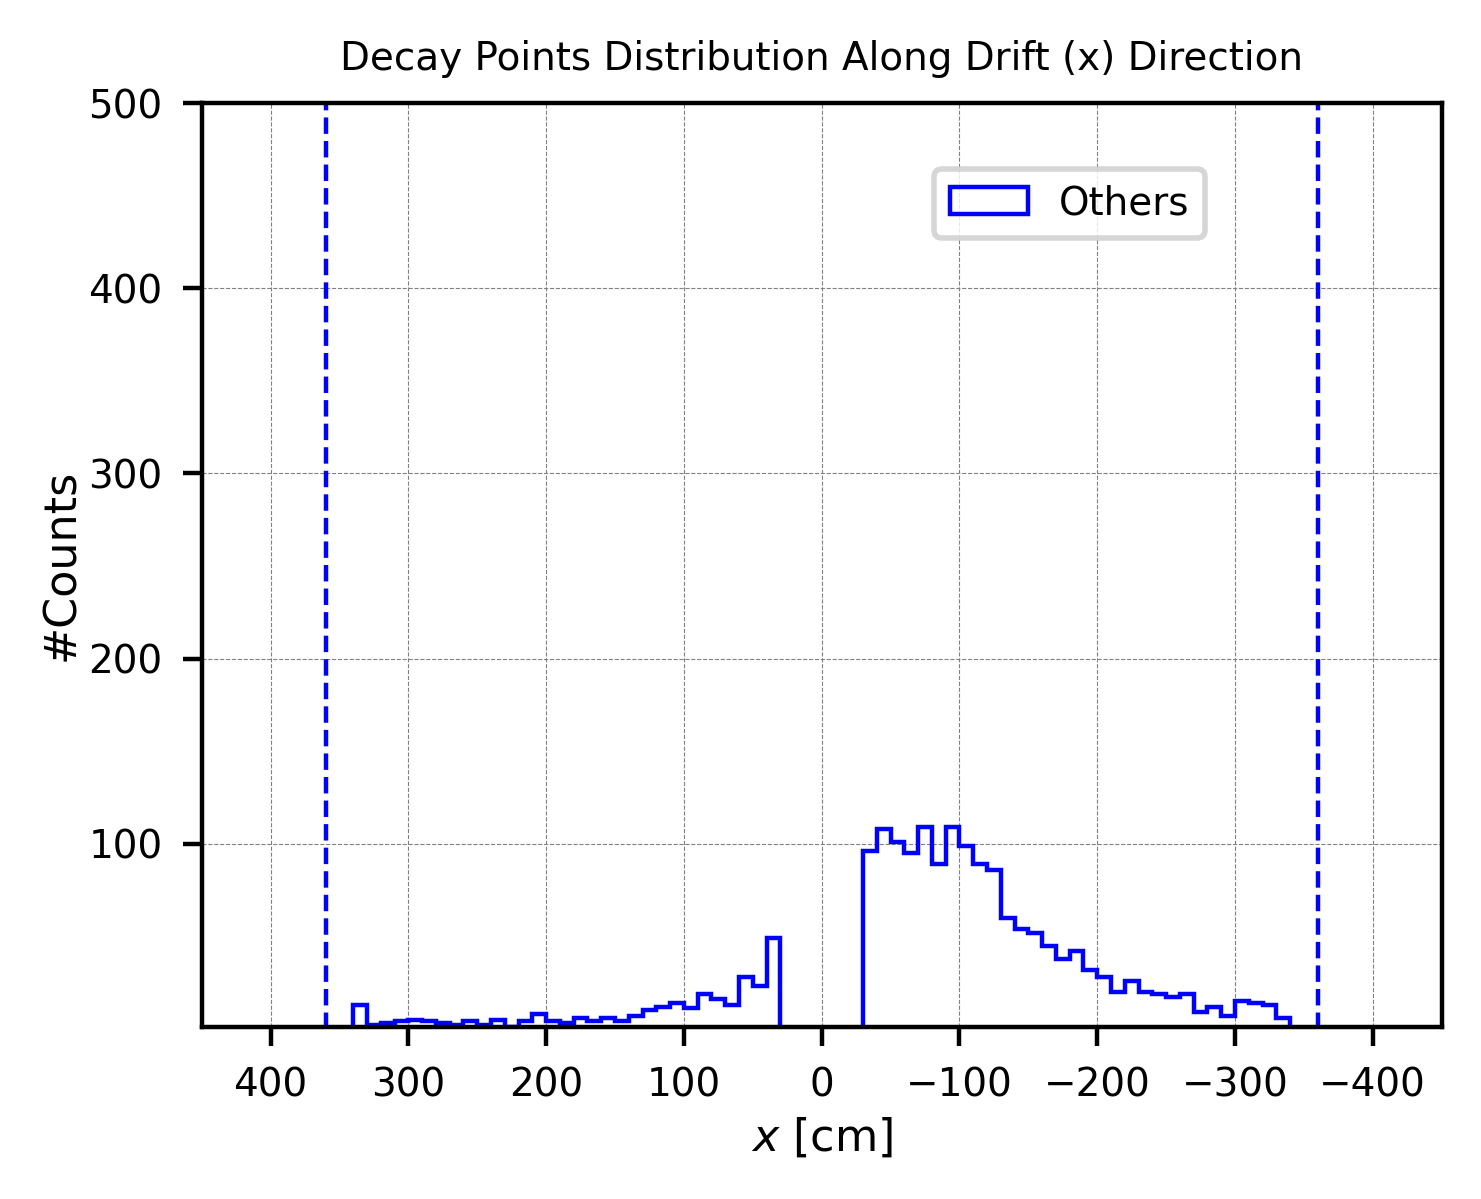

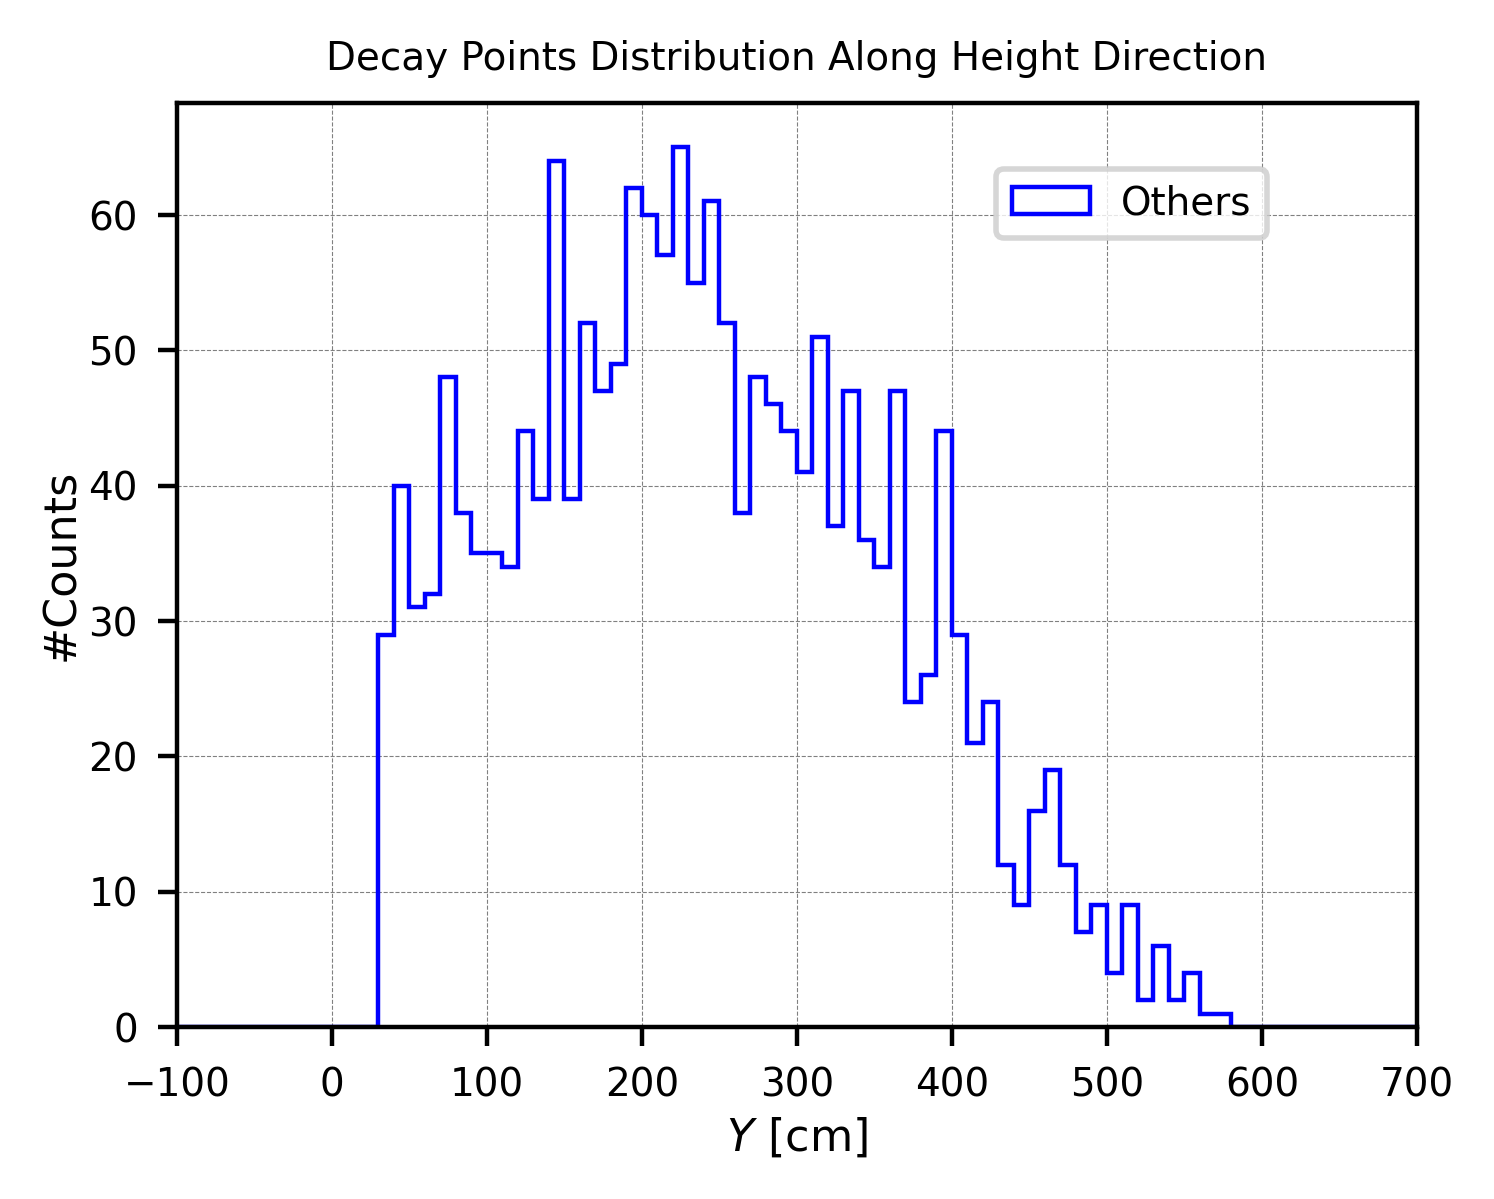

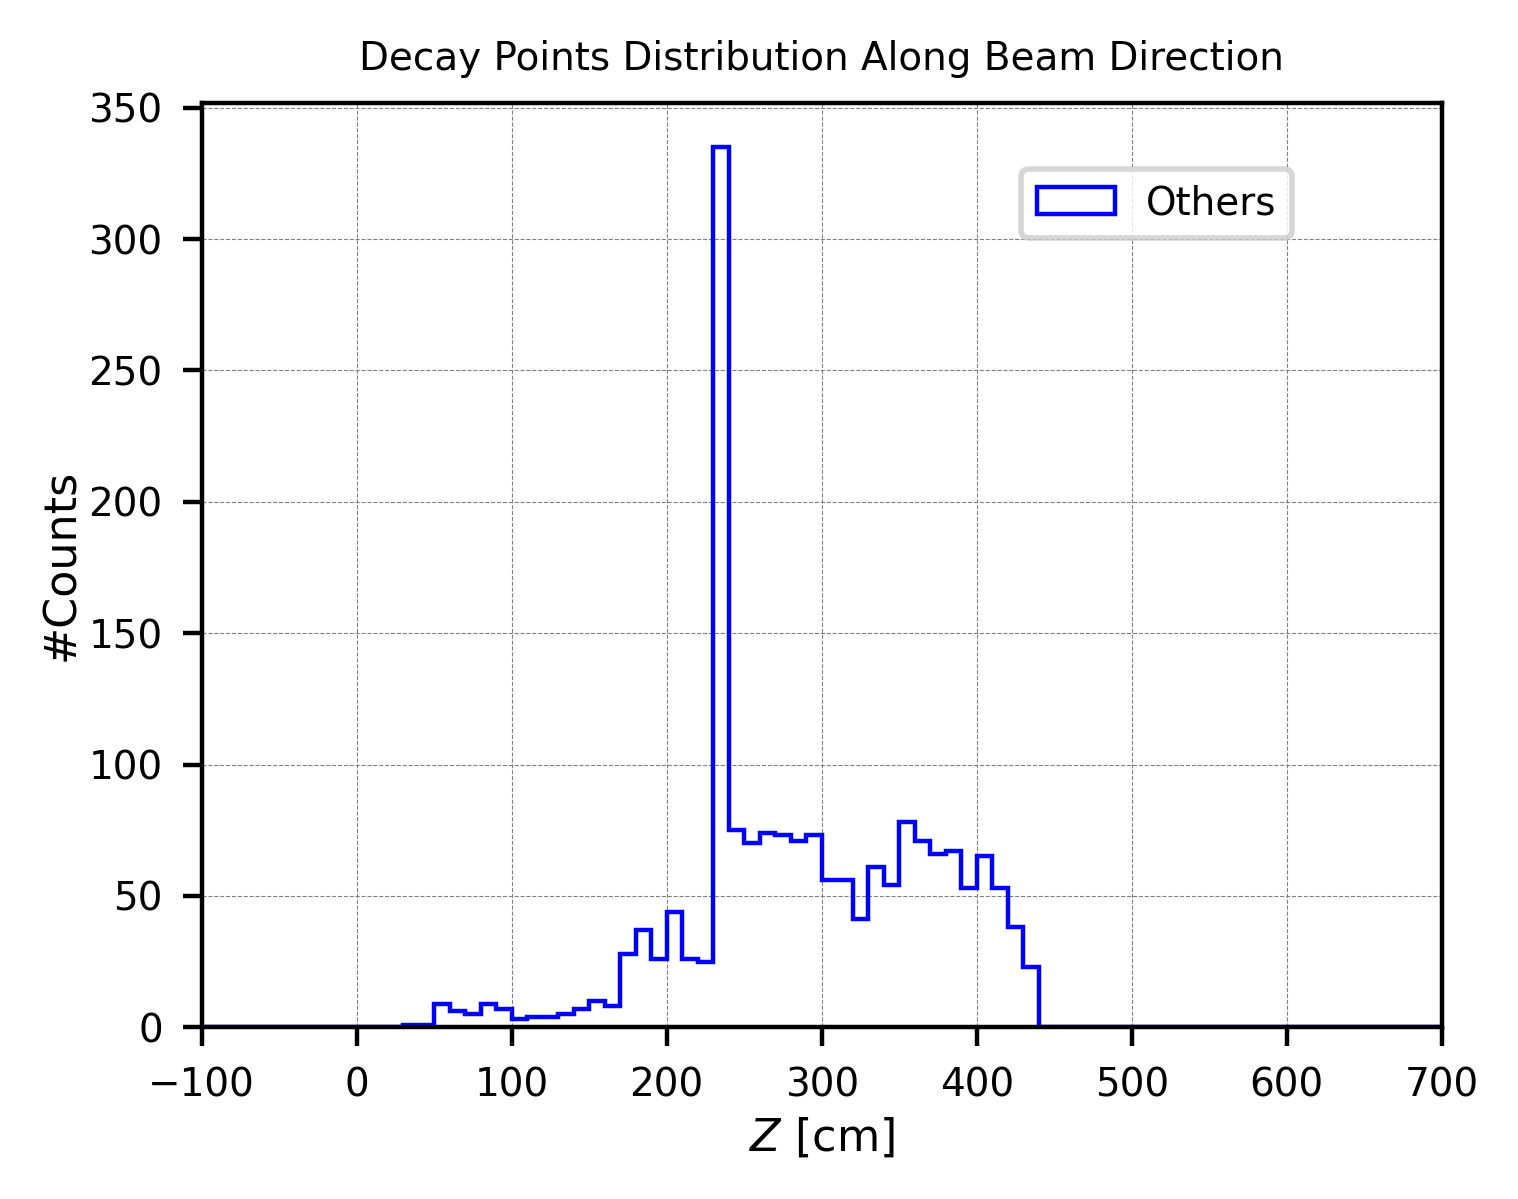

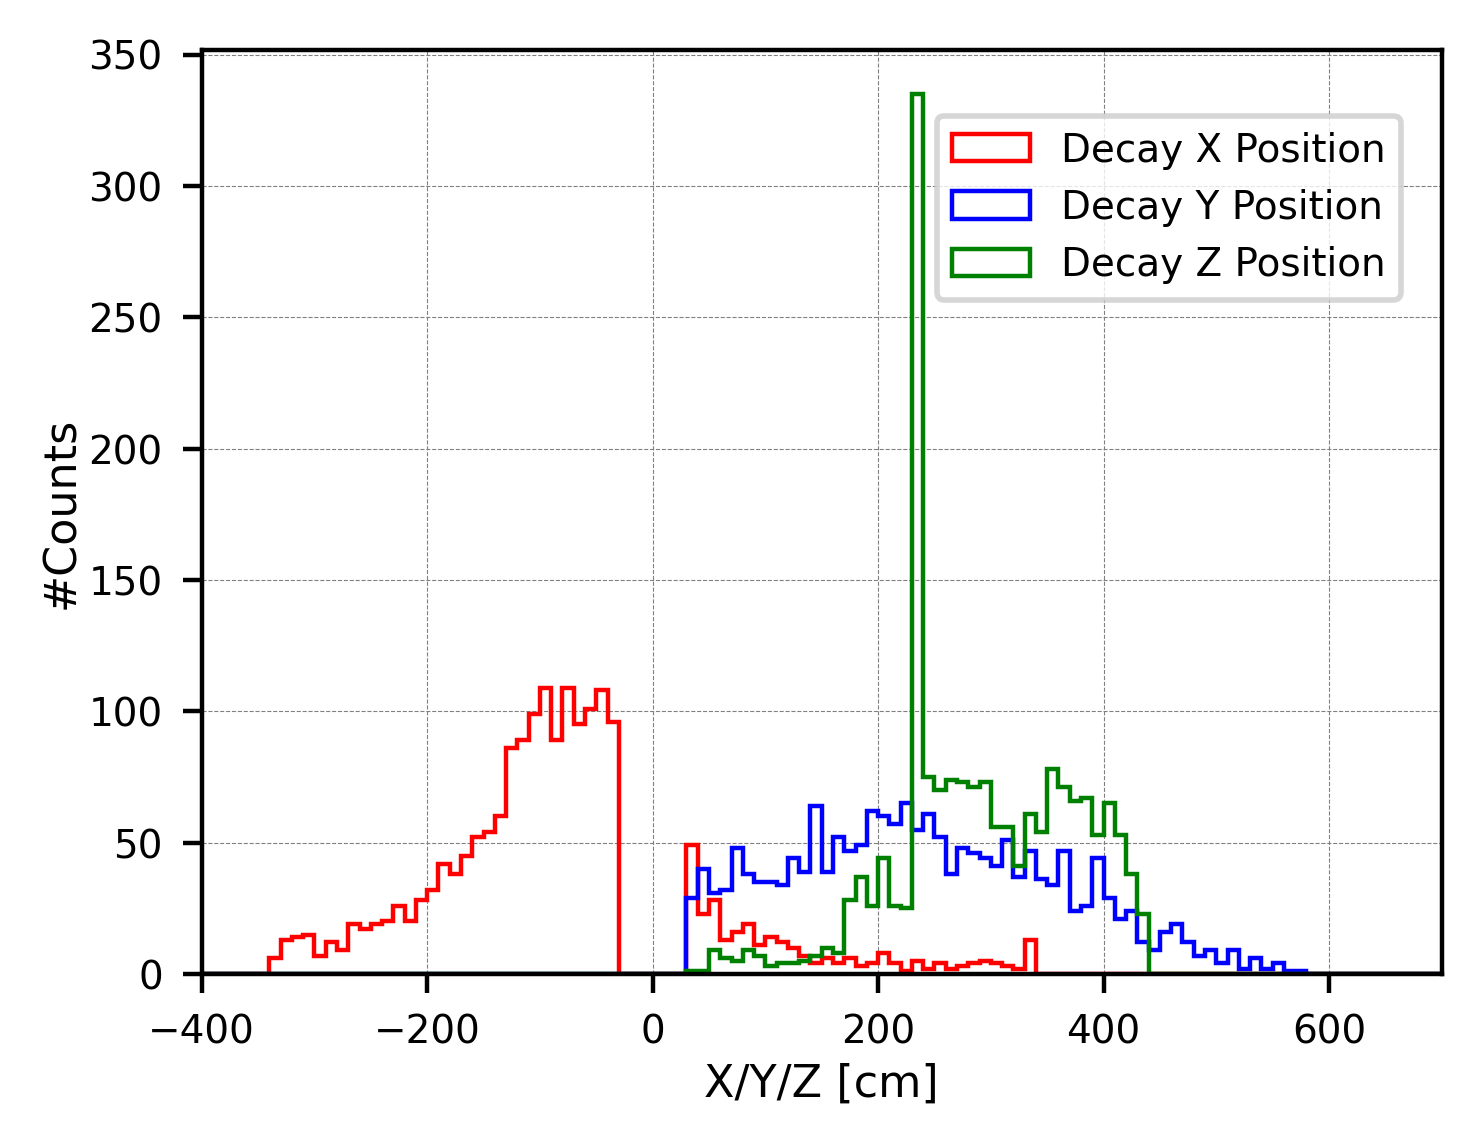

In [29]:

posX_total_purify9 = [ev.posX for ev in events_total_purify9]
posY_total_purify9 = [ev.posY for ev in events_total_purify9]
posZ_total_purify9 = [ev.posZ for ev in events_total_purify9]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 500)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Y distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posY_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Y$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Height Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Z distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posZ_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Z$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Beam Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 










#X/Y/Z in one plotting:==========================================
# Plotting the histogram (Z distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='red', 
          histtype='step', linewidth=0.8, label="Decay X Position")
plt.hist(posY_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Decay Y Position")
plt.hist(posZ_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='green', 
          histtype='step', linewidth=0.8, label="Decay Z Position")
#--------------------------------

plt.xlim(-400, 700)
plt.xlabel('X/Y/Z [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
#plt.title('Decay Points Distribution Along Beam Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 











# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line for field cage
# aux2 = [0, 610, 610, 0, 0]
# aux1 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(xmin, xmax)
# plt.ylim(-50, 660)
# plt.gca().invert_xaxis()  # Flip x-axis
# plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Front View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux1 = [0, 465, 465, 0, 0]
# aux2 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.ylim(xmin, xmax)
# plt.xlim(-50, 515)
# plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.title('Top View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()




# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
# aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(-50, 515)
# plt.ylim(-50, 660)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Side View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


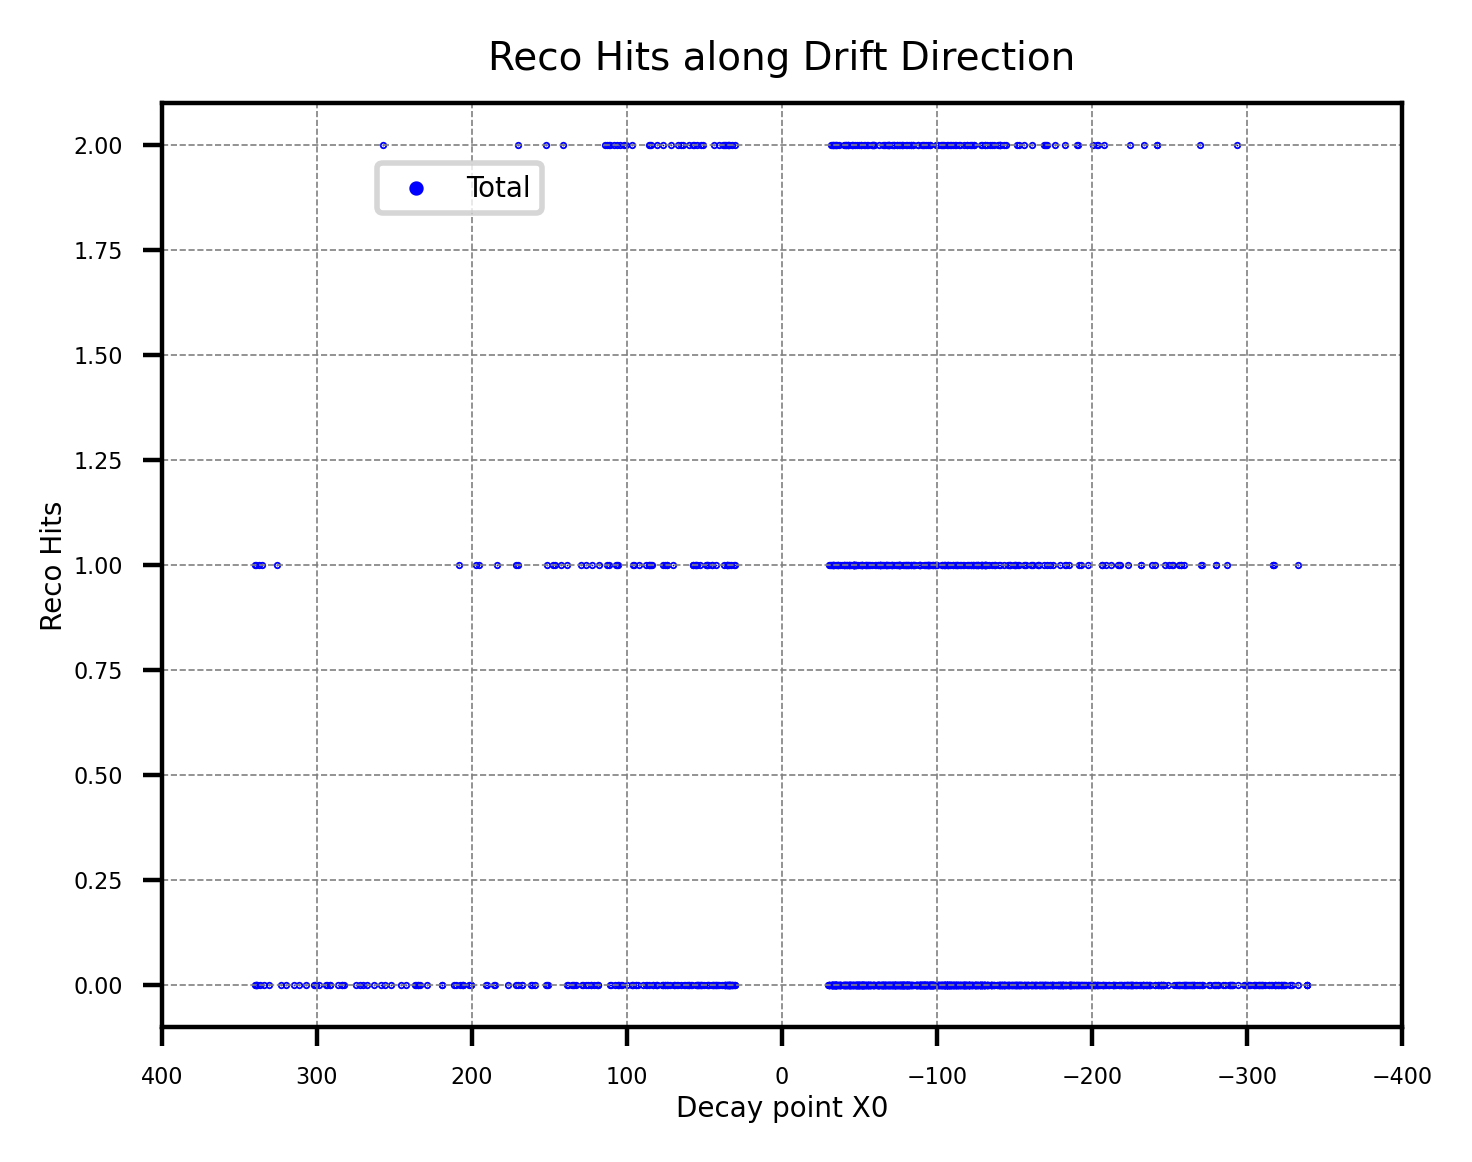


Michel Score Distribution: 


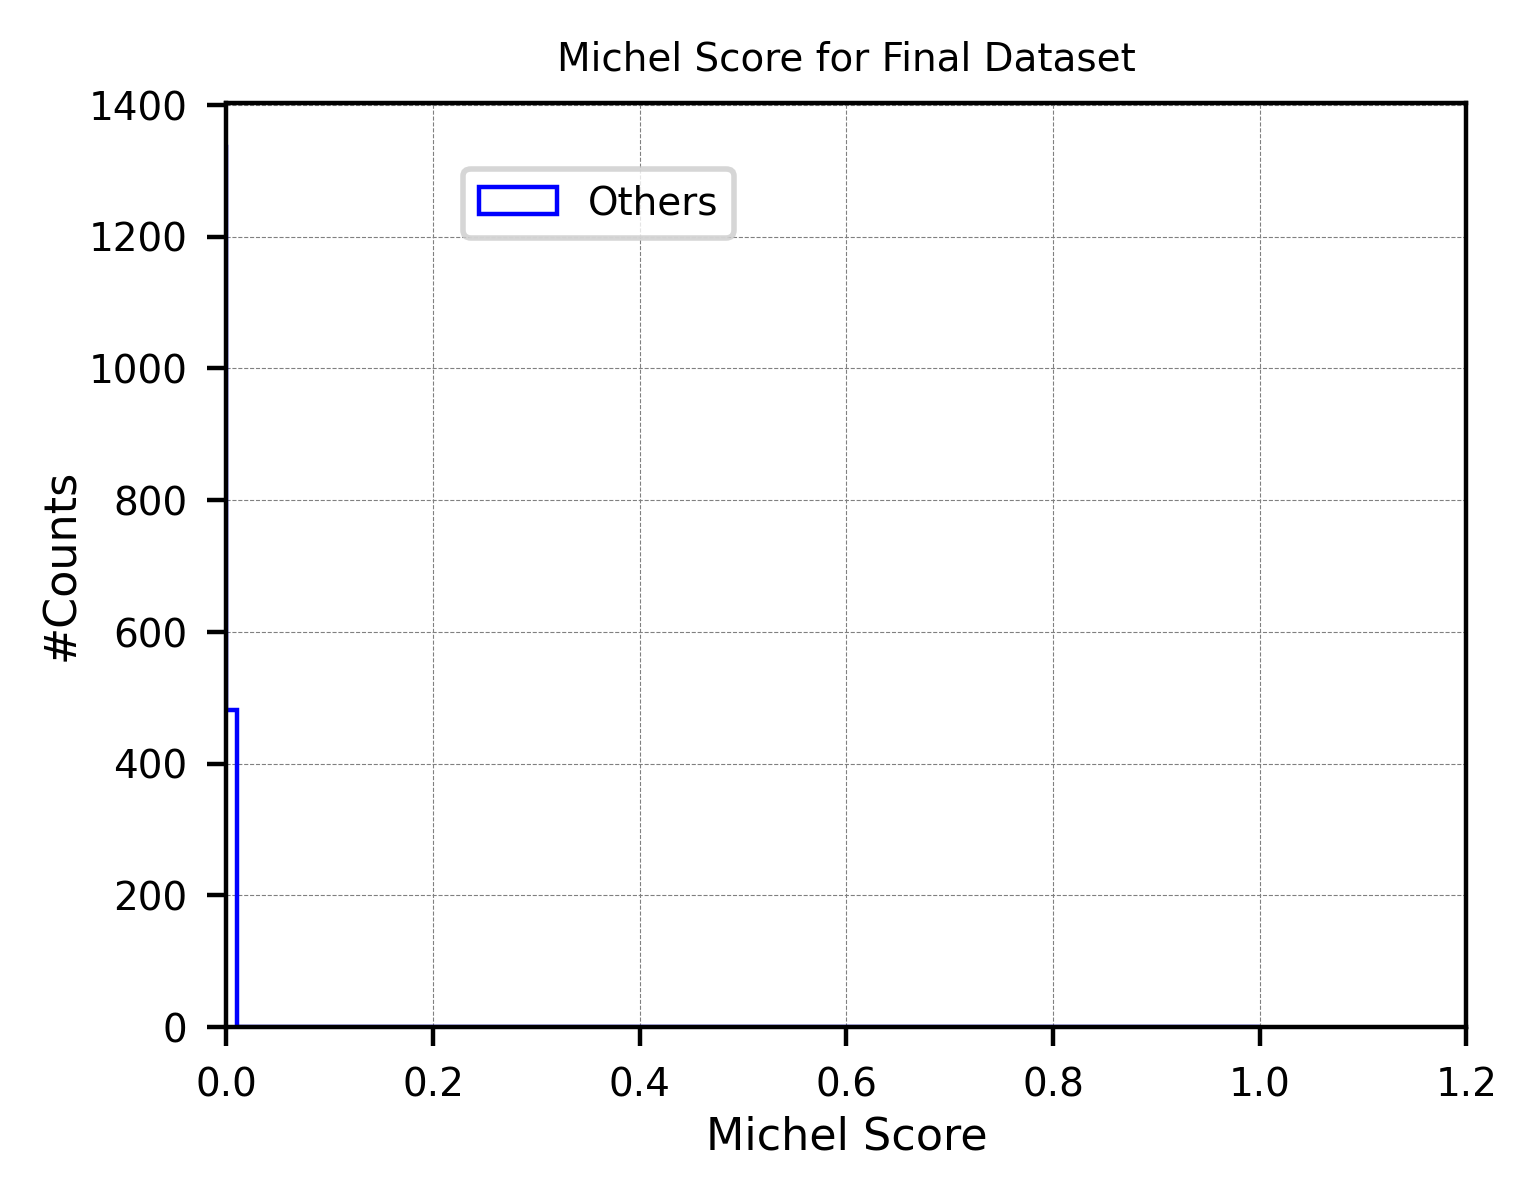


Michel Hits Distribution: 


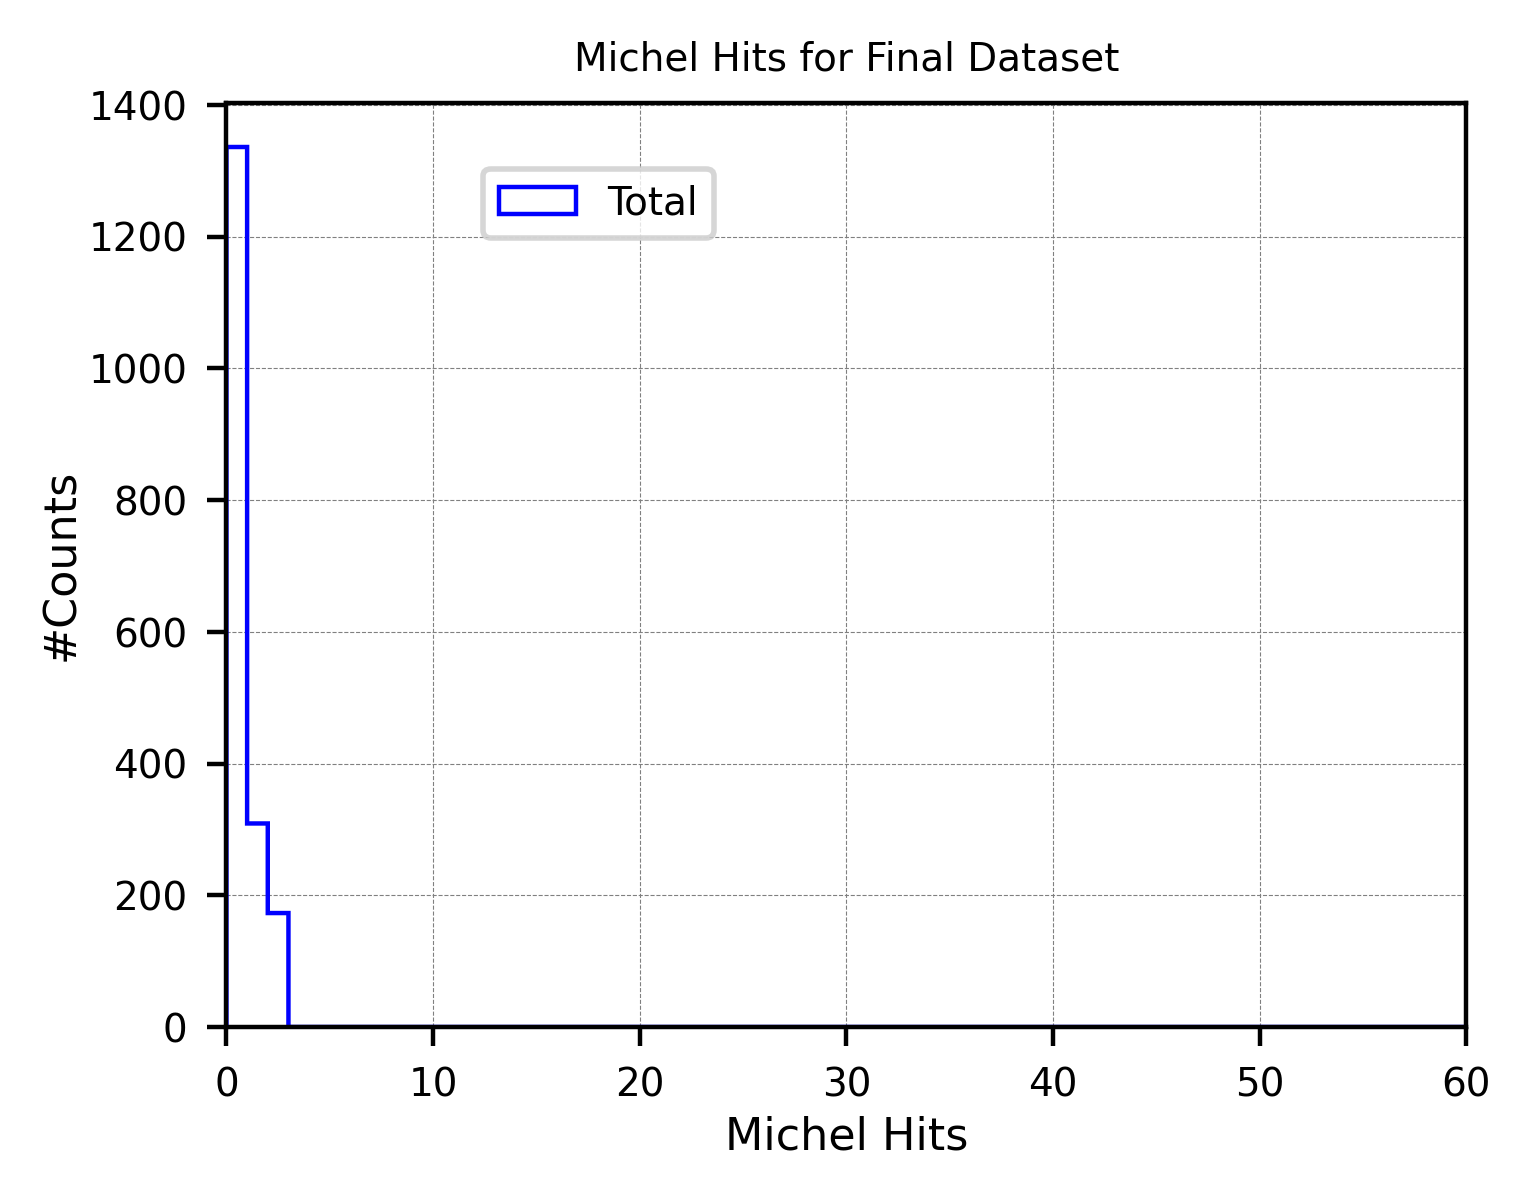

In [24]:

hits_total_purify9 = [ev.michel_hits for ev in events_total_purify9]

score_total_purify9 = [ev.michel_score for ev in events_total_purify9]











# ==========================================================
# reco hits VS posX
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(posX_total_purify9, hits_total_purify9, s=0.1, c='blue', alpha=1.0, label="Total")
#-----------------------

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0, 2000)
plt.ylabel('Reco Hits', labelpad=1, fontsize=5)
plt.xlabel('Decay point X0', labelpad=1, fontsize=5)
plt.title('Reco Hits along Drift Direction', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=6, markerscale=5, ncol=1, prop={'size':5})
plt.show()








#Michel Score distribution:==========================================
print("\nMichel Score Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min =-1
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(score_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------

plt.xlim(0, 1.2)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Score for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 







#Michel Hits distribution:==========================================
print("\nMichel Hits Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min =0
range_max = 600
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(hits_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")

#--------------------------------

plt.xlim(0, 60)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Hits for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 





<br />
<br />
<br />

#### Lifetime Distribution of Final Dataset (purification 9):



For each event, +40ns for reco time


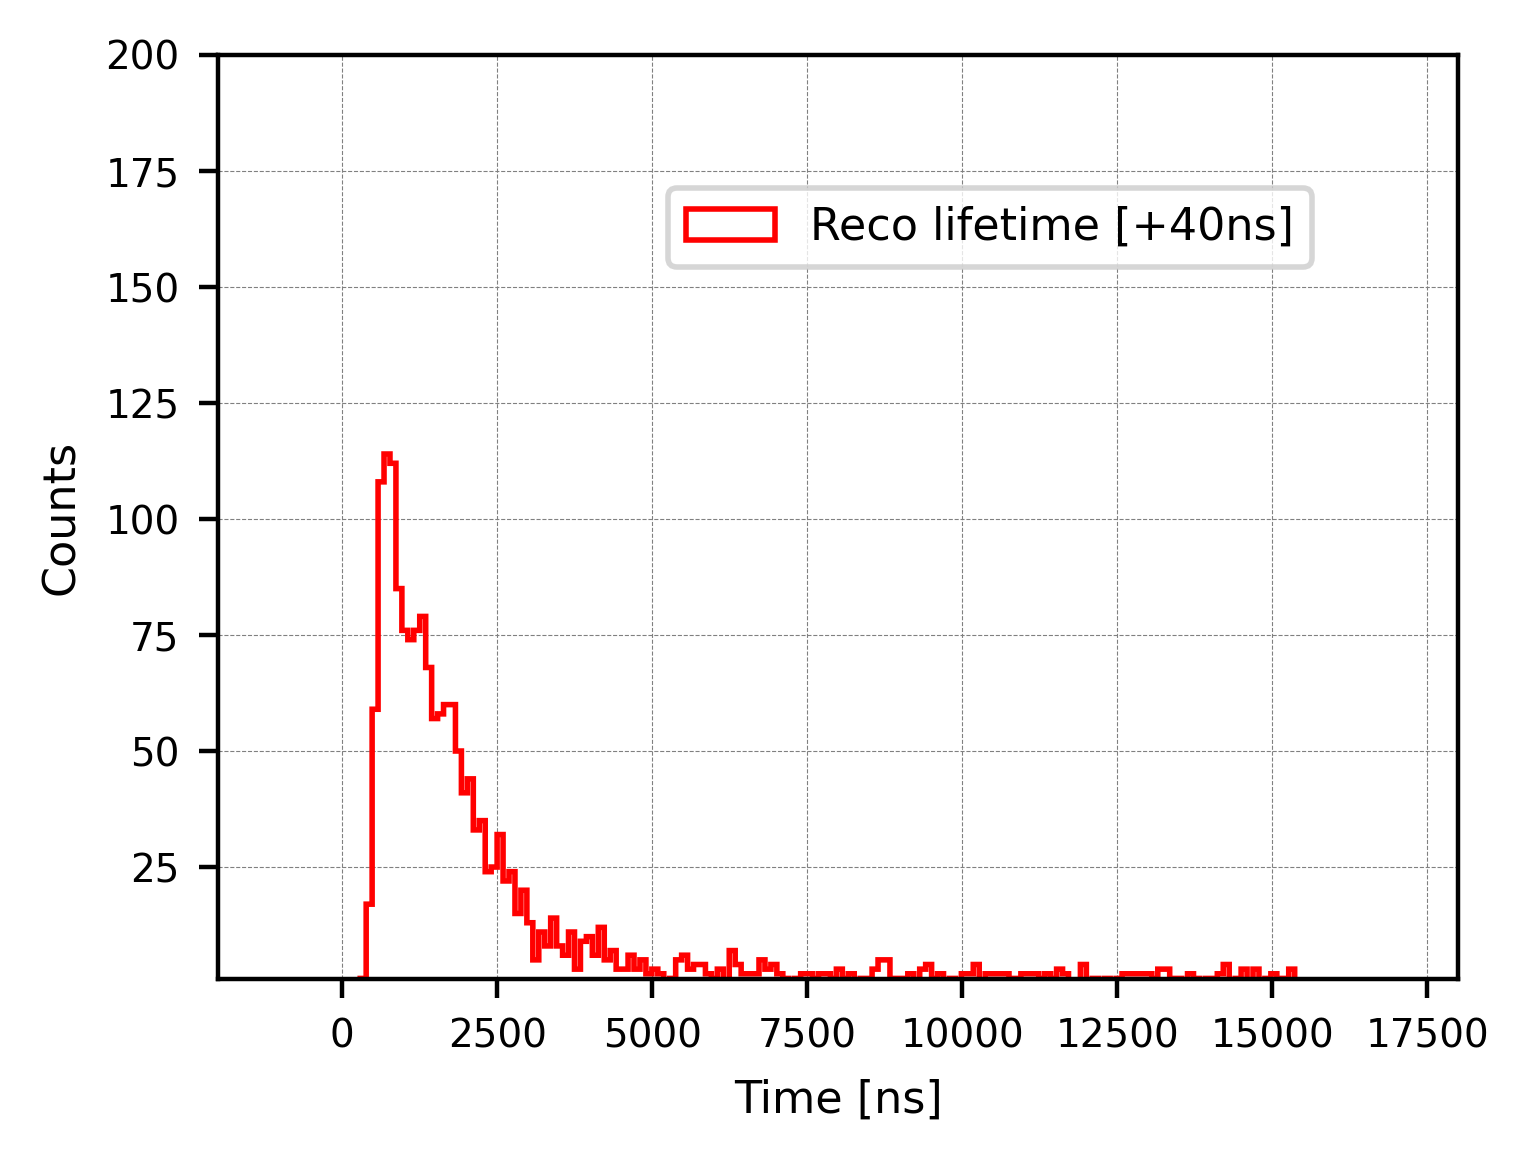



recoT_purify9_shift40_DataBkgSample.npy saved successfully.
Length of recoT_total_purify9_shift40:  1818


In [28]:

recoT_total_purify9 = [ev.reco_lifetime for ev in events_total_purify9]






#Shift +40ns=========================================
print("\n\n===================================")
print("For each event, +40ns for reco time")
recoT_total_purify9_shift40 = [x + 40 for x in recoT_total_purify9]


bin_width = 96
range_min = -960000
range_max = 960000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.figure(figsize=(4, 3), dpi=400)
#plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
#         edgecolor='blue', histtype='step', linewidth=1.0,
#         label='Reco muon lifetime')

#plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
#         edgecolor='blue', histtype='step', linewidth=1.0,
#         label='Reco muon lifetime')
plt.hist(recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=1.0,
         label='Reco lifetime [+40ns]')

#plt.axvline(384, linestyle='--', color='k', linewidth=0.8)

#plt.xlim(0, 16000) 
plt.xlim(-2000, 18000) 
plt.ylim(0.9, 200)
#plt.yscale("log")
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()





#Save bkg sample (+40ns shifted reco time)===
np.save("recoT_purify9_shift40_DataBkgSample.npy", np.array(recoT_total_purify9_shift40))
print("\n\nrecoT_purify9_shift40_DataBkgSample.npy saved successfully.")
print("Length of recoT_total_purify9_shift40: ", len(recoT_total_purify9_shift40))


<br />
<br />

<br />

### Apply detection efficiency:
